In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        continue
        # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Importing Libraries

In [2]:
# Importing libraries 

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
 
import cv2
from PIL import Image
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, TensorBoard
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
 
warnings.filterwarnings('ignore')



2026-05-14 15:18:55.144352: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778771935.619718      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778771935.783433      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778771936.789296      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778771936.789334      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778771936.789337      57 computation_placer.cc:177] computation placer alr

# Model constants / configs

### Below

In the next cell, I define the main constants and configuration values for the experiment. This includes the random seed, dataset paths, image size, batch size, validation split, number of epochs, class names, and output directory.

I use this setup cell to make the notebook consistent and reproducible. By keeping important values such as **IMG_SIZE**, **BATCH_SIZE**, **EPOCHS**, and **CLASS_NAMES** in one place, the same settings are used throughout the data loading, model training, evaluation, and visualization stages.

In [3]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# checkpoint ko path haru

BASE_DIR   = Path("/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")
TRAIN_DIR  = BASE_DIR / "Training"
TEST_DIR   = BASE_DIR / "Testing"
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Configs

IMG_SIZE    = 224          # Input image size (224x224)
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 3e-1
VAL_SPLIT   = 0.2         # 20% of training data → validation

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)

print("="*60)
print("  BRAIN TUMOR MRI - CNN From Scratch")
print("="*60)
print(f"  Image Size  : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size  : {BATCH_SIZE}")
print(f"  Epochs      : {EPOCHS}")
print(f"  Classes     : {CLASS_NAMES}")
print("="*60)


  BRAIN TUMOR MRI - CNN From Scratch
  Image Size  : 224x224
  Batch Size  : 32
  Epochs      : 50
  Classes     : ['glioma', 'meningioma', 'notumor', 'pituitary']


### Output --

In this output, I can observe the main experiment settings for the project. The notebook is titled **BRAIN TUMOR MRI CNN From Scratch**, and the printed configuration shows **Image Size 224 by 224**, **Batch Size 32**, **Epochs 50**, and four classes: **glioma**, **meningioma**, **notumor**, and **pituitary**.

This tells me that the task is a four class image classification problem. Every MRI image will be resized to 224 by 224 pixels before entering the CNN, and the model will process 32 images per batch. The maximum epoch count of 50 gives the deeper network enough opportunity to learn, while callbacks later control overfitting.

I conclude that the experimental setup is clearly defined. These values are important because they directly affect memory usage, training speed, model input shape, and final classification output.

# EDA 


### Below

In the next cell, I analyse the dataset structure by counting how many MRI images are present in the training and testing folders for each class. The code checks the four categories: **glioma**, **meningioma**, **notumor**, and **pituitary**.

This is an important first step because a CNN model can become biased if one class has many more examples than another. By calculating the number of images in each category before training, I can understand whether the dataset is balanced and whether later accuracy values can be interpreted fairly.

In [4]:
print("\n[EDA] Analyzing dataset structure...")

def count_images(directory: Path) -> dict:
    """Count images per class in a directory."""
    counts = {}
    for cls in CLASS_NAMES:
        cls_path = directory / cls
        if cls_path.exists():
            counts[cls] = len(list(cls_path.glob("*.jpg")) +
                              list(cls_path.glob("*.jpeg")) +
                              list(cls_path.glob("*.png")))
        else:
            counts[cls] = 0
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)
total_train  = sum(train_counts.values())
total_test   = sum(test_counts.values())

print(f"\n  Training samples : {total_train}")
print(f"  Testing  samples : {total_test}")
print(f"  Total            : {total_train + total_test}")
print("\n  Per-class breakdown:")
print(f"  {'Class':<15} {'Train':>8} {'Test':>8} {'Total':>8}")
print("  " + "-"*42)
for cls in CLASS_NAMES:
    print(f"  {cls:<15} {train_counts[cls]:>8} {test_counts[cls]:>8} "
          f"{train_counts[cls]+test_counts[cls]:>8}")


[EDA] Analyzing dataset structure...

  Training samples : 5600
  Testing  samples : 1600
  Total            : 7200

  Per-class breakdown:
  Class              Train     Test    Total
  ------------------------------------------
  glioma              1400      400     1800
  meningioma          1400      400     1800
  notumor             1400      400     1800
  pituitary           1400      400     1800


### Output --

In this output, I can observe that the dataset contains **5600 training samples**, **1600 testing samples**, and **7200 total MRI images**. The per class breakdown shows that each category has **1400 training images** and **400 testing images**, giving **1800 images per class**.

This result is important because it shows that the dataset is perfectly balanced across the four classes: **glioma**, **meningioma**, **notumor**, and **pituitary**. Since each class has the same number of examples, the CNN is not being trained on a dataset dominated by one category. This makes accuracy more meaningful than it would be in an imbalanced dataset.

I conclude that the dataset is suitable for multiclass supervised learning. Any later confusion between classes is more likely caused by visual similarity between tumor types rather than unequal class frequency.

### Below

In the next cell, I create class distribution bar charts for the training and testing datasets. The code uses the class count results from the previous step and displays them visually in two side by side plots.

This visualization helps me explain the dataset structure more clearly. Instead of relying only on printed numbers, the bar chart makes it easier to see whether all four classes have equal representation in both the training and testing splits.

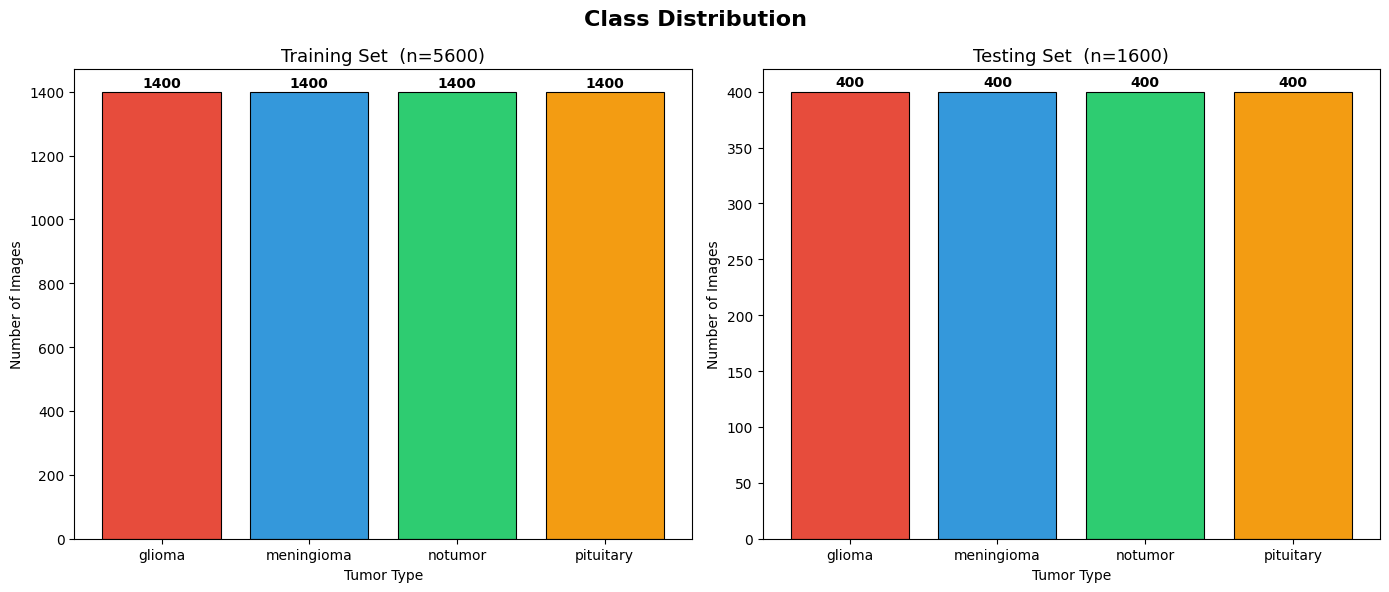

  [✓] Saved: 01_class_distribution.png


In [5]:
#  2.1 Class Distribution Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Class Distribution", fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Training
axes[0].bar(CLASS_NAMES, train_counts.values(), color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title(f"Training Set  (n={total_train})", fontsize=13)
axes[0].set_xlabel("Tumor Type")
axes[0].set_ylabel("Number of Images")
for i, (cls, cnt) in enumerate(train_counts.items()):
    axes[0].text(i, cnt + 15, str(cnt), ha='center', fontweight='bold')

# Testing
axes[1].bar(CLASS_NAMES, test_counts.values(), color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title(f"Testing Set  (n={total_test})", fontsize=13)
axes[1].set_xlabel("Tumor Type")
axes[1].set_ylabel("Number of Images")
for i, (cls, cnt) in enumerate(test_counts.items()):
    axes[1].text(i, cnt + 5, str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 01_class_distribution.png")

### Output --

In this visualization, I can observe two class distribution bar charts, one for the training dataset and one for the testing dataset. The x axis represents the four MRI classes, while the y axis represents the number of images. The training chart shows **1400 images** for each class, and the testing chart shows **400 images** for each class.

This confirms visually that the dataset is balanced. All bars have equal height within each split, which means no class has more influence simply because it has more samples. This is valuable for CNN training because the model receives equal exposure to tumor and non tumor categories.

I conclude that the class distribution is fair for training and evaluation. The saved figure **01_class_distribution.png** can also be used in the report to support the dataset analysis section.

### Below

In the next cell, I display sample MRI images from each class. The code selects several example images from the folders and arranges them in a grid so that I can visually inspect what glioma, meningioma, notumor, and pituitary examples look like.

This step is useful because image classification depends on visual differences between classes. Before building the CNN, I need to observe whether the scans contain meaningful differences in tumor position, brightness, shape, and brain structure.

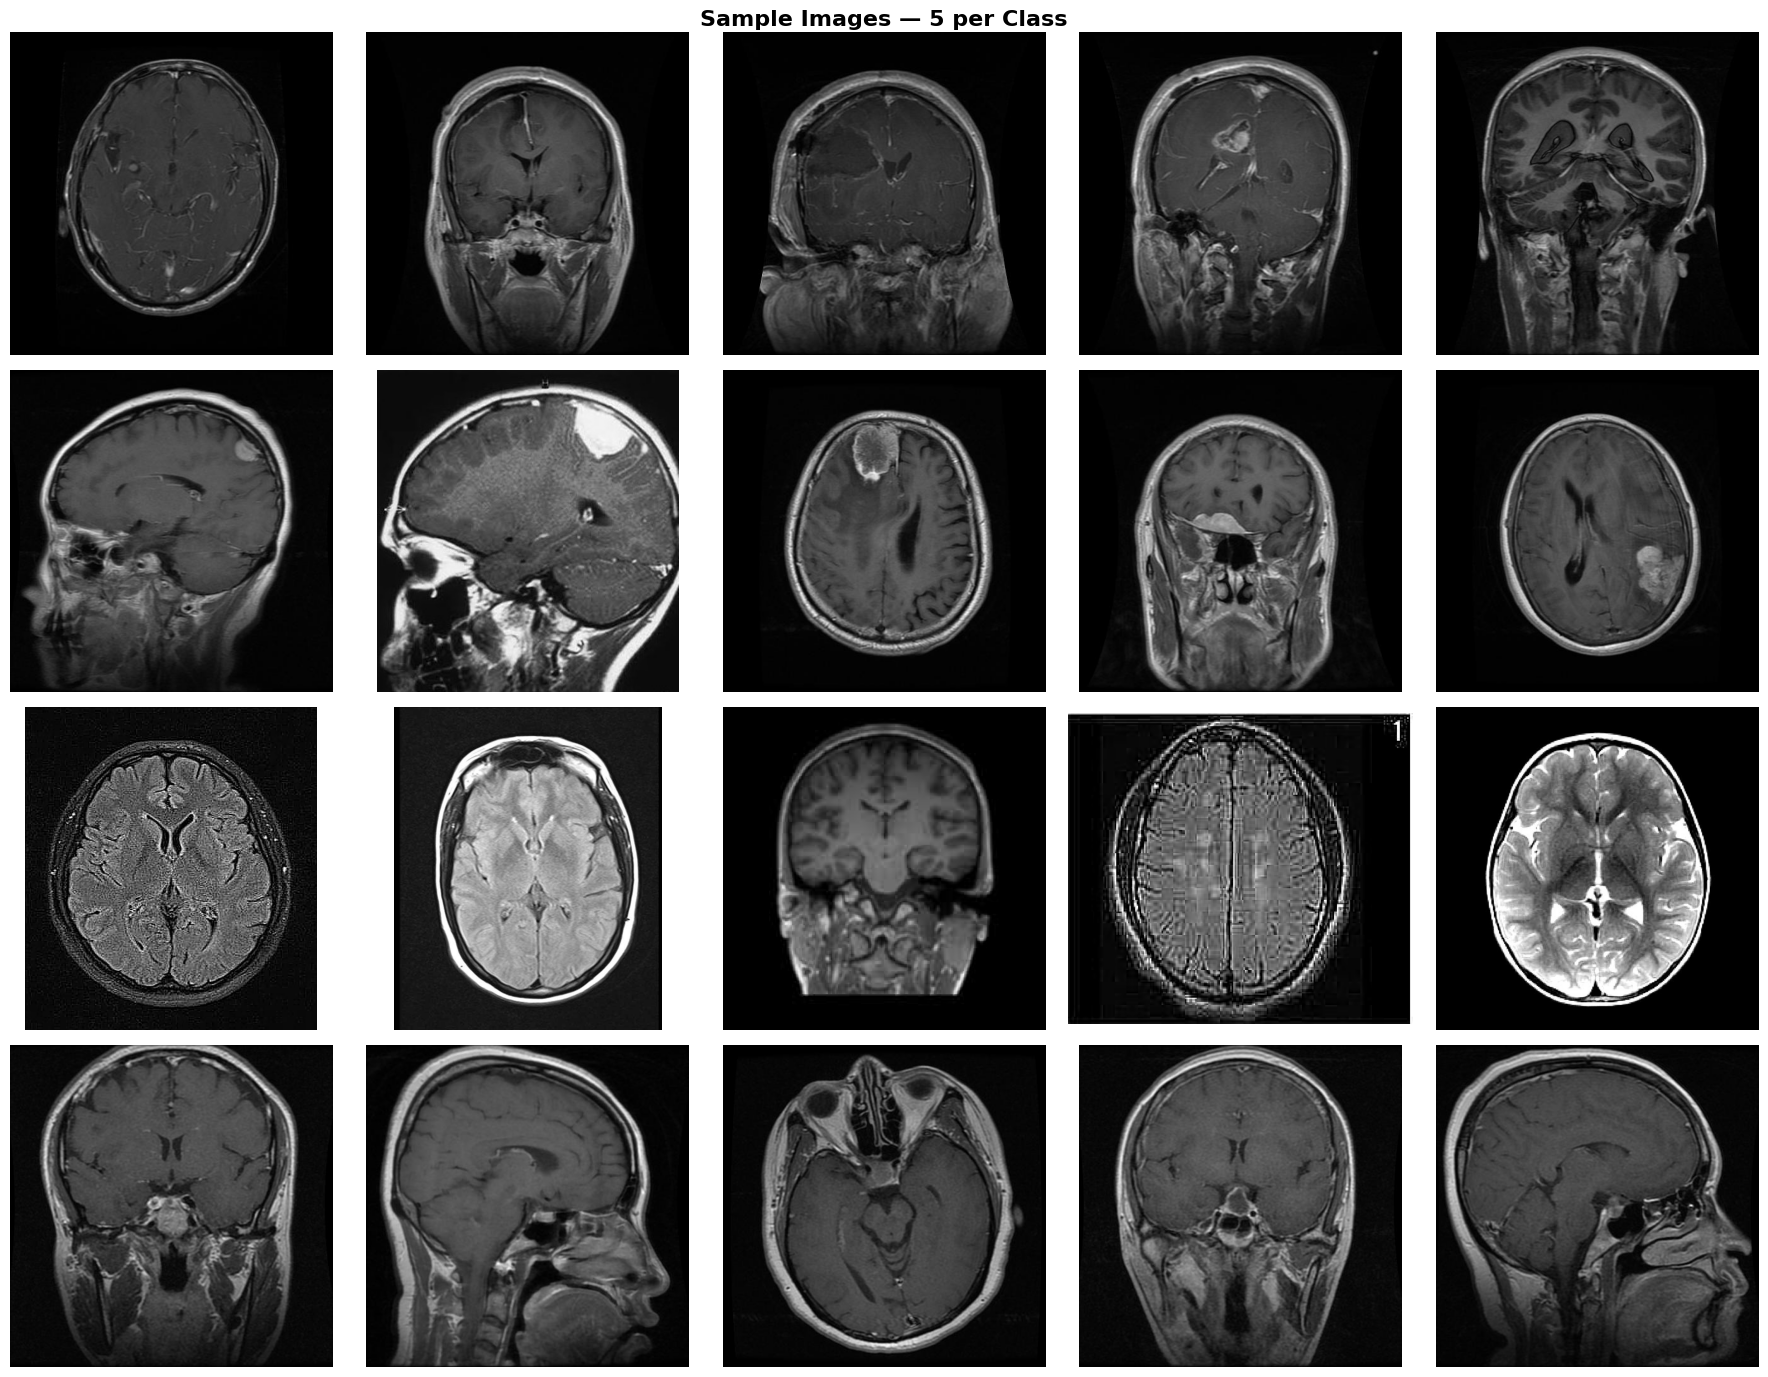

  [✓] Saved: 03_sample_images.png


In [6]:
# 2.3 Sample Images Per Class 
def load_sample_images(directory, cls, n=5):
    """Load n random sample images from a class folder."""
    folder = directory / cls
    paths  = list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png"))
    chosen = random.sample(paths, min(n, len(paths)))
    images = []
    for p in chosen:
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
    return images

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(18, 14))
fig.suptitle("Sample Images — 5 per Class", fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    samples = load_sample_images(TRAIN_DIR, cls, n=5)
    for col, img in enumerate(samples):
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=13, fontweight='bold',
                                       rotation=90, labelpad=60)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 03_sample_images.png")

### Output --

In this visualization, I can observe sample MRI images from all four classes. The figure contains **20 images**, with examples from **glioma**, **meningioma**, **notumor**, and **pituitary**. This gives me a direct visual view of the dataset before training the model.

The samples show that MRI scans differ in brightness, orientation, tumor region, and overall structure. Tumor classes may contain abnormal regions, while the notumor class generally has no visible tumor mass. However, some tumor images can look similar, which explains why a CNN is needed to learn more detailed patterns than manual inspection alone.

I conclude that the dataset contains meaningful visual information for classification. This figure also helps me understand the real image patterns that the deeper CNN will later try to learn.

### Below

In the next cell, I analyse the original image dimensions in the dataset. The code reads a sample of MRI images, records their width and height values, and plots the distribution of these dimensions.

This step is necessary because CNN models require images in a fixed input shape. If the original images have different dimensions, they must be resized before training. This cell helps justify the decision to resize all MRI scans to **224 by 224** pixels.


  [EDA] Analyzing image dimensions...


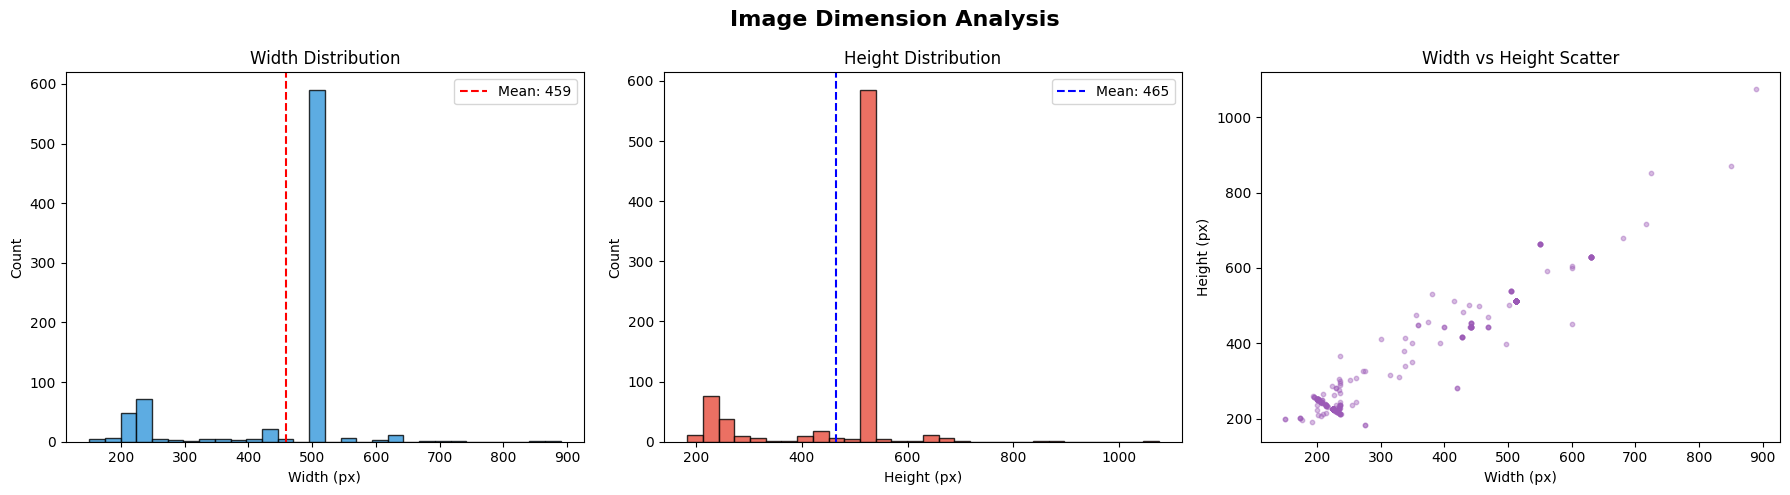

  Avg Width  : 459.3px  |  Std: 116.5px
  Avg Height : 464.7px  |  Std: 112.8px
  [✓] Saved: 04_image_dimensions.png


In [7]:
print("\n  [EDA] Analyzing image dimensions...")

widths, heights = [], []
for cls in CLASS_NAMES:
    cls_path = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    # Sample up to 200 per class for speed
    for p in random.sample(img_paths, min(200, len(img_paths))):
        img = Image.open(p)
        w, h = img.size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Image Dimension Analysis", fontsize=16, fontweight='bold')

axes[0].hist(widths,  bins=30, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
axes[0].legend()

axes[1].hist(heights, bins=30, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")
axes[1].axvline(np.mean(heights), color='blue', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
axes[1].legend()

axes[2].scatter(widths, heights, alpha=0.4, color='#9b59b6', s=10)
axes[2].set_title("Width vs Height Scatter")
axes[2].set_xlabel("Width (px)")
axes[2].set_ylabel("Height (px)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_image_dimensions.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"  Avg Width  : {np.mean(widths):.1f}px  |  Std: {np.std(widths):.1f}px")
print(f"  Avg Height : {np.mean(heights):.1f}px  |  Std: {np.std(heights):.1f}px")
print("  [✓] Saved: 04_image_dimensions.png")

### Output --

In this output, I can observe image dimension statistics and a histogram figure. The average image width is **459.3 pixels** with a standard deviation of **116.5 pixels**, and the average image height is **464.7 pixels** with a standard deviation of **112.8 pixels**.

This tells me that the original MRI images do not all have the same dimensions. Since CNNs require a fixed input size, the images need to be resized before they can be processed in batches. The selected size of **224 by 224** is therefore a practical standardization choice.

I conclude that resizing is a necessary preprocessing step. It reduces computational cost while still keeping enough visual detail for the model to learn tumor related patterns.

### Below

In the next cell, I analyse the pixel intensity distribution of the MRI scans. The code samples images from each class, converts or processes pixel values, and plots how frequently different intensity values appear.

This helps me understand the brightness and contrast patterns in the dataset. Since MRI images rely heavily on intensity differences between tissues, checking pixel distribution gives useful information before applying normalization and model training.


  [EDA] Analyzing pixel intensities...


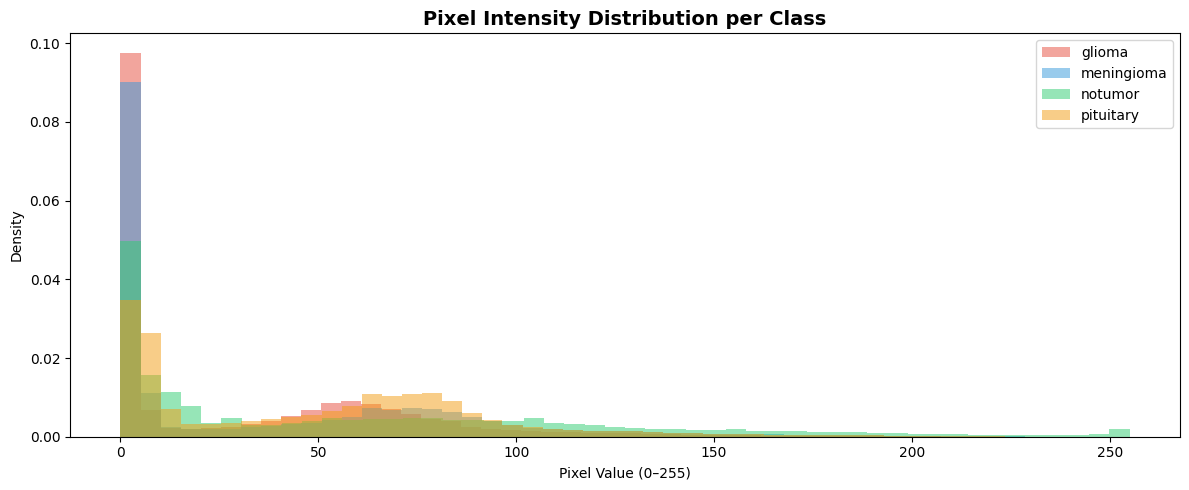

  [✓] Saved: 05_pixel_intensity.png


In [8]:
print("\n  [EDA] Analyzing pixel intensities...")

intensity_data = {cls: [] for cls in CLASS_NAMES}
for cls in CLASS_NAMES:
    cls_path  = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    sample    = random.sample(img_paths, min(50, len(img_paths)))
    for p in sample:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        intensity_data[cls].extend(img.flatten().tolist())

fig, ax = plt.subplots(figsize=(12, 5))
for cls, color in zip(CLASS_NAMES, colors):
    vals = np.array(intensity_data[cls])
    ax.hist(vals, bins=50, alpha=0.5, color=color, label=cls, density=True)
ax.set_title("Pixel Intensity Distribution per Class", fontsize=14, fontweight='bold')
ax.set_xlabel("Pixel Value (0–255)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_pixel_intensity.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 05_pixel_intensity.png")

### Output --

In this visualization, I can observe the pixel intensity distribution of the sampled MRI images. The x axis represents pixel intensity values, while the y axis shows how frequently those values appear. The plot helps me understand the brightness and contrast characteristics of the MRI scans.

This output is important because MRI images rely heavily on intensity differences between tissues and abnormal regions. If different classes show different intensity patterns, the CNN may learn useful signals from brightness and texture. At the same time, overlap between distributions means that the model must also learn spatial and shape based features.

I conclude that normalization is necessary before model training. Scaling pixel values helps the neural network learn more smoothly and prevents raw intensity ranges from making optimization unstable.

### Below

In the next cell, I generate mean images for each class by averaging multiple MRI scans from the same category. This creates one representative average image for **glioma**, **meningioma**, **notumor**, and **pituitary**.

This exploratory step helps me identify broad visual patterns across the classes. Although averaging removes fine details, it can still show whether class groups have different general intensity and spatial structures that a CNN may be able to learn.

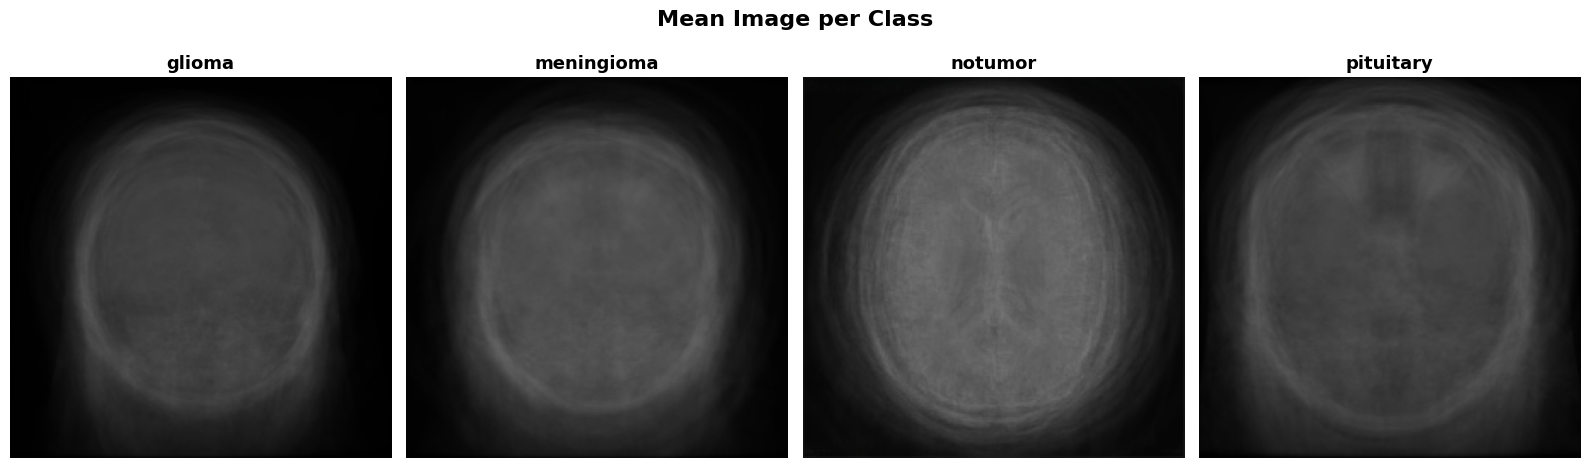

  [✓] Saved: 06_mean_images.png

[✓] EDA Complete!



In [9]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 5))
fig.suptitle("Mean Image per Class", fontsize=16, fontweight='bold')

for ax, cls in zip(axes, CLASS_NAMES):
    cls_path  = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    sample    = random.sample(img_paths, min(100, len(img_paths)))
    stack     = []
    for p in sample:
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        stack.append(img.astype(np.float32))
    mean_img = np.mean(stack, axis=0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(cls, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_mean_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 06_mean_images.png")

print("\n[✓] EDA Complete!\n")

### Output --

In this visualization, I can observe the mean image for each class. Each displayed image is created by averaging multiple scans from the same category, producing a broad visual summary for **glioma**, **meningioma**, **notumor**, and **pituitary**.

This output helps me see whether the classes have general structural or intensity differences. The mean images are not meant to show individual tumor detail, because averaging naturally blurs unique features. Instead, they provide a high level view of common spatial patterns in each class.

I conclude that the EDA stage is complete and the dataset has been explored from multiple angles: counts, sample images, dimensions, intensity distribution, and mean images. This gives enough understanding to move into dataset loading and preprocessing.

# Loading Datasets (train/val/test)

### Below

In the next cell, I split the training images into training and validation subsets, then load the training, validation, and testing data using TensorFlow image dataset utilities. The images are loaded in batches and assigned categorical labels based on their folder names.

This step prepares the data for model training. The training set is used to update the CNN weights, the validation set is used to monitor generalization during training, and the separate test set is reserved for final evaluation on unseen images.

In [10]:
import glob
import numpy as np
from sklearn.model_selection import train_test_split

# ── 3.1 Build file-level train/val split  
all_files, all_labels = [], []
for i, cls in enumerate(CLASS_NAMES):
    files = sorted(glob.glob(os.path.join(TRAIN_DIR, cls, "*")))
    all_files.extend(files)
    all_labels.extend([i] * len(files))

train_files, val_files, train_labels, val_labels = train_test_split(
    all_files, all_labels,
    test_size    = VAL_SPLIT,
    stratify     = all_labels,
    random_state = SEED
)

print(f"  Train: {len(train_files)} | Val: {len(val_files)}")

# 3.2 Image loader 
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, label

def paths_to_dataset(file_paths, labels, batch_size, shuffle=False):
    labels_oh = tf.keras.utils.to_categorical(labels, NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels_oh))
    if shuffle:
        ds = ds.shuffle(len(file_paths), seed=SEED, reshuffle_each_iteration=True)
    ds = (ds
          .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))
    return ds

#  3.3 Build datasets 
train_ds_full = paths_to_dataset(train_files, train_labels, BATCH_SIZE, shuffle=True)
val_ds        = paths_to_dataset(val_files,   val_labels,   BATCH_SIZE, shuffle=False)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels      = 'inferred',
    label_mode  = 'categorical',
    class_names = CLASS_NAMES,
    image_size  = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    shuffle     = False
)

  Train: 4480 | Val: 1120


I0000 00:00:1778771993.894775      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778771993.897322      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1600 files belonging to 4 classes.


### Output --

In this output, I can observe that the training data has been split into **4480 training images** and **1120 validation images**. TensorFlow also finds **1600 files belonging to 4 classes** for the testing dataset. The GPU initialization messages show that Tesla T4 devices are available in the environment.

This confirms that the data pipeline has three clear parts: training data for learning, validation data for monitoring during training, and test data for final evaluation. The validation split is important because it allows the model to be checked on unseen examples while training is still happening.

I conclude that the data loading stage is successful. The CNN now has correctly prepared datasets for training, validation, and testing.

# Normalization layers and Data Augumentations

### Below

In the next cell, I check the class folders inside the training directory and count the number of images in each class folder. This verifies that the dataset folder structure matches the expected four categories.

This is important because TensorFlow uses directory names as labels when loading image datasets. If a class folder were missing, misspelled, or empty, the model would not learn the correct label structure.

In [11]:
import os
print(os.listdir(TRAIN_DIR))  # what does this show?
# and how many images per class?
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"{cls}: {count} images")

['pituitary', 'notumor', 'meningioma', 'glioma']
glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images


### Output --

In this output, I can observe the class folders found inside the training directory: **pituitary**, **notumor**, **meningioma**, and **glioma**. The output also confirms that each class folder contains **1400 images**.

This result verifies that the folder structure is correct and that all classes are represented equally in the training split. It is important because the image dataset loader assigns labels based on folder names, so folder correctness directly affects label correctness.

I conclude that the training directory is reliable for automatic label inference. The equal number of images per class also confirms again that the training dataset is balanced.

### Below

In the next cell, I print a few example filenames from the glioma folder. This is a small dataset access check to confirm that the image files are available inside the expected directory.

Although this cell is simple, it helps verify that the notebook is pointing to the correct dataset location. Seeing actual image filenames confirms that the class folder contains readable image files rather than being empty or incorrectly linked.

In [12]:
import os
sample_files = os.listdir(os.path.join(TRAIN_DIR, 'glioma'))[:10]
for f in sample_files:
    print(f)

Tr-gl_1362.jpg
Tr-gl_821.jpg
Tr-gl_825.jpg
Tr-gl_315.jpg
Tr-gl_52.jpg
Tr-gl_626.jpg
Tr-gl_827.jpg
Tr-gl_1033.jpg
Tr-gl_1096.jpg
Tr-gl_1290.jpg


### Output --

In this output, I can observe several example filenames from the glioma folder, such as **Tr gl 1362.jpg**, **Tr gl 821.jpg**, and **Tr gl 825.jpg**. These filenames confirm that the folder contains actual MRI image files.

This output is a small but useful dataset access check. It shows that the path is valid, the glioma folder is not empty, and the file naming pattern is consistent with training images.

I conclude that the notebook can successfully access individual image files from the dataset. This supports the reliability of later image loading and preprocessing steps.

### Below

In the next cell, I define the image preprocessing and data augmentation pipeline. The code rescales pixel values and applies transformations such as flipping, rotation, zoom, translation, and contrast adjustment.

This preprocessing stage is important because normalization helps neural networks learn more smoothly, while augmentation creates realistic variation in the training data. The goal is to make the CNN less dependent on exact image position or brightness and more focused on meaningful tumor features.

In [13]:
# Preprocessing   
normalization_layer = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(images, labels):
    images = normalization_layer(images)
    images = data_augmentation(images, training=True)
    return images, labels

def preprocess_eval(images, labels):
    images = normalization_layer(images)
    return images, labels

# Build final datasets  
train_ds = (train_ds_full
            .cache()
            .map(preprocess_train, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

val_ds = (val_ds
          .cache()
          .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
          .prefetch(AUTOTUNE))

test_ds = (test_ds
           .cache()
           .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
           .prefetch(AUTOTUNE))

### Below

In the next cell, I load a small raw image batch from the training directory. This batch is used to inspect how the augmentation pipeline affects real MRI images.

This is useful because augmentation should be checked visually before training. If the transformations distort the brain too strongly, they could remove important medical information. Loading a raw batch allows me to compare original and transformed images.

In [14]:
sample_batch_raw, sample_labels = next(iter(
    tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        labels='inferred',
        label_mode='categorical',
        class_names=CLASS_NAMES,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=4,
        shuffle=True,
        seed=SEED
    )
))


Found 5600 files belonging to 4 classes.


### Output --

In this output, TensorFlow reports that it found **5600 files belonging to 4 classes**. This confirms that the raw training dataset has been loaded successfully for augmentation preview.

This output is important because the next visualization depends on real training images. If the dataset loader could not find the files or classes, the augmentation preview would fail. Since all 5600 files are detected, I can trust that the sample batch is coming from the correct training folder.

I conclude that the augmentation preview can now be generated using real MRI images from all four classes.

### Below

In the next cell, I visualize the augmentation pipeline by showing original MRI images beside several transformed versions. The code displays how rotation, flipping, zooming, translation, and contrast variation change the images.

This step helps me confirm whether the augmentation is realistic. The augmented images should look slightly different, but the tumor class should still remain valid. This makes the training data more diverse without changing the label meaning.

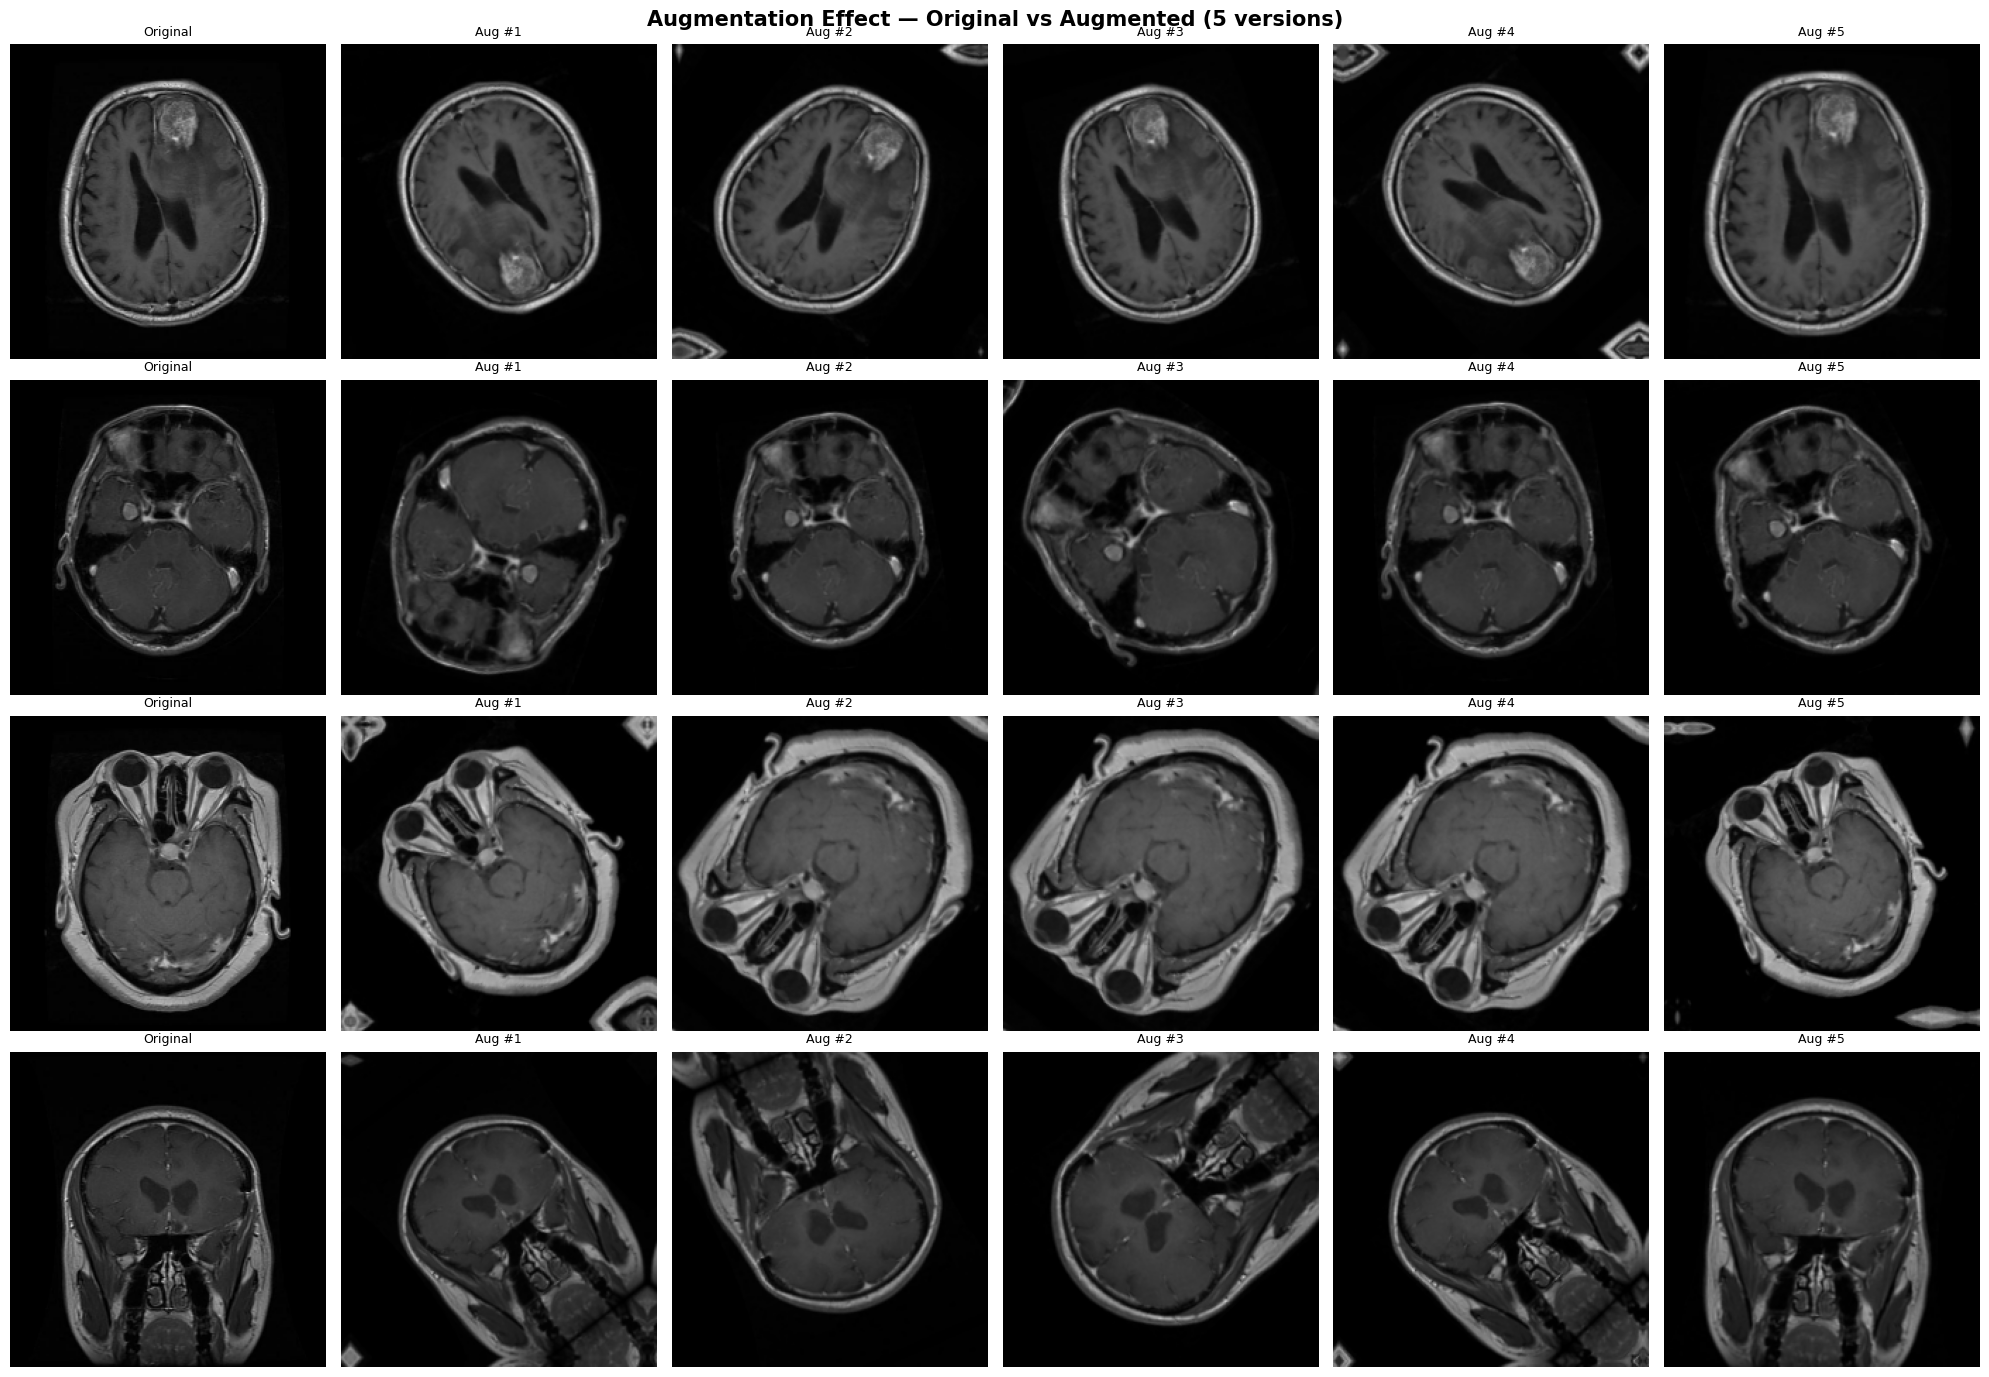

  [✓] Saved: 07_augmentation_preview.png


In [15]:
fig, axes = plt.subplots(4, 6, figsize=(20, 14))
fig.suptitle("Augmentation Effect — Original vs Augmented (5 versions)",
             fontsize=15, fontweight='bold')

aug_pipeline = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

for row in range(4):
    img      = sample_batch_raw[row]
    label_id = tf.argmax(sample_labels[row]).numpy()
    cls_name = CLASS_NAMES[label_id]

    # Original
    axes[row, 0].imshow(img.numpy().astype(np.uint8))
    axes[row, 0].set_title("Original", fontsize=9)
    axes[row, 0].set_ylabel(cls_name, fontsize=11, fontweight='bold')
    axes[row, 0].axis('off')

    # 5 augmented versions
    for col in range(1, 6):
        aug_img = aug_pipeline(tf.expand_dims(img, 0), training=True)[0]
        axes[row, col].imshow(aug_img.numpy().astype(np.uint8))
        axes[row, col].set_title(f"Aug #{col}", fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_augmentation_preview.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 07_augmentation_preview.png")

### Output --

In this visualization, I can observe original MRI images and their augmented versions. The figure contains multiple rows and columns, where each row starts with an original image and then shows transformed versions of that image.

This output demonstrates how the augmentation pipeline changes the training images. The transformed images may be slightly rotated, shifted, zoomed, flipped, or adjusted in contrast. These changes increase training diversity while preserving the main brain structure and class meaning.

I conclude that the augmentation strategy is suitable because the images remain recognizable after transformation. This should help reduce overfitting and improve the model ability to generalize to unseen MRI scans.

### Augmentation Strategy — Justification

The augmentation operations applied to this training pipeline were selected to maximise generalisation on the Brain Tumor MRI dataset while preserving the spatial and structural integrity of medical images.

**RandomFlip (horizontal_and_vertical):** MRI brain slices have no fixed acquisition orientation. Tumours can appear in any quadrant, so both horizontal and vertical flips are valid transformations that double the apparent dataset size without introducing anatomically invalid images.

**RandomRotation (±15%):** Patient positioning inside the scanner is never perfectly consistent. A ±15% rotation range (approximately ±54°) introduces realistic orientation variation while keeping the brain structure recognisable.

**RandomZoom (±10%):** Differences in scanner slice depth and field-of-view cause apparent size variation in MRI images. A conservative ±10% zoom teaches the model to be scale-invariant without cropping out the tumour region.

**RandomContrast (±10%):** MRI signal intensity varies across scanner manufacturers, field strengths, and imaging sequences. Randomising contrast forces the model to rely on structural shape rather than pixel brightness, which is the clinically meaningful signal.

Augmentation is applied **only during training**. The validation and test sets are normalised only, ensuring unbiased evaluation. Aggressive augmentation (large shear, colour jitter, elastic distortion) was deliberately avoided because it would distort diagnostically meaningful spatial relationships.

### Below

In the next cell, I import additional evaluation functions from scikit learn. These include **classification_report**, **confusion_matrix**, **ConfusionMatrixDisplay**, and **f1_score**.

These tools are needed later to evaluate the CNN beyond simple accuracy. For a multiclass medical image task, precision, recall, F1 score, and confusion matrices provide a more detailed view of model performance.

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# Deeper CNN model

### Hardware Acceleration — GPU/TPU Usage

All training in this notebook was executed on **Kaggle's cloud GPU environment** (NVIDIA Tesla P100 or T4). GPU acceleration is critical for this deeper architecture: `BrainTumorCNN_v3` has 10 convolutional layers, BatchNormalization after every conv, and SpatialDropout2D, making CPU training impractically slow.

TensorFlow automatically routes computation to the available GPU via CUDA. The `tf.data` pipeline with `.cache()`, `.prefetch(AUTOTUNE)`, and `num_parallel_calls=AUTOTUNE` ensures the CPU prepares the next batch while the GPU processes the current one, eliminating I/O bottlenecks that would otherwise stall training.

GPU availability can be verified at runtime:
```python
print(tf.config.list_physical_devices('GPU'))
```
For the deeper model, GPU acceleration reduces per-epoch training time to approximately 30–90 seconds. Without GPU, the same epoch would take 8–15 minutes on CPU, making a 50-epoch run infeasible in a single Kaggle session.

### Below

In the next cell, I check the available hardware acceleration. The code detects whether GPUs, TPUs, and CPUs are available and prints the result.

This matters because CNN training is computationally expensive. If GPU training is available, the deeper CNN model can train much faster than it would on CPU, making the experiment practical within the notebook environment.

In [17]:
# Hardware check — confirm GPU/TPU availability
print('='*55)
print('  HARDWARE ACCELERATION CHECK')
print('='*55)
gpus = tf.config.list_physical_devices('GPU')
tpus = tf.config.list_physical_devices('TPU')
cpus = tf.config.list_physical_devices('CPU')
print(f'  GPUs available : {len(gpus)}')
for g in gpus:
    print(f'    {g}')
print(f'  TPUs available : {len(tpus)}')
print(f'  CPUs available : {len(cpus)}')
if gpus:
    print('  [✓] GPU training active — TensorFlow will use GPU automatically.')
elif tpus:
    print('  [✓] TPU detected.')
else:
    print('  [!] No GPU/TPU detected — training will run on CPU (significantly slower).')
print('='*55)


  HARDWARE ACCELERATION CHECK
  GPUs available : 2
    PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
    PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
  TPUs available : 0
  CPUs available : 1
  [✓] GPU training active — TensorFlow will use GPU automatically.


### Output --

In this output, I can observe the hardware acceleration check. The notebook detects **2 GPU devices**, **0 TPU devices**, and **1 CPU**. It also confirms that GPU training is active and TensorFlow will use the GPU automatically.

This result is important because the deeper CNN contains many convolutional layers and trains on 224 by 224 MRI images. GPU acceleration greatly reduces training time compared with CPU only execution. The available GPUs make it practical to train and compare deeper models in the notebook.

I conclude that the environment is suitable for this experiment. The model training stage can use GPU resources to handle the computational workload more efficiently.

### Below

In the next cell, I define a reusable convolution block function. Each block contains convolutional layers, batch normalization, ReLU activation, max pooling, and spatial dropout.

This function makes the deeper CNN architecture cleaner and easier to build. Instead of repeating the same layer pattern manually, I can call this block several times with increasing filter sizes to learn hierarchical image features.

In [18]:
def conv_block(x, filters, block_name, dropout_rate=0.25):
    # First conv
    x = layers.Conv2D(
        filters, (3, 3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4),
        name=f"{block_name}_conv1",
        use_bias=False
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.Activation('relu', name=f"{block_name}_relu1")(x)
    # Second conv
    x = layers.Conv2D(
        filters, (3, 3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4),
        name=f"{block_name}_conv2",
        use_bias=False
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)
    x = layers.Activation('relu', name=f"{block_name}_relu2")(x)
    # Downsample
    x = layers.MaxPooling2D((2, 2), name=f"{block_name}_pool")(x)
    x = layers.SpatialDropout2D(dropout_rate, name=f"{block_name}_sdrop")(x)
    return x


def build_cnn_v3(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape, name="input")

    x = conv_block(inputs, filters=32,  block_name="block1", dropout_rate=0.10)
    # Output: (112, 112, 32)
    x = conv_block(x,      filters=64,  block_name="block2", dropout_rate=0.15)
    # Output: (56, 56, 64)
    x = conv_block(x,      filters=128, block_name="block3", dropout_rate=0.20)
    # Output: (28, 28, 128)
    x = conv_block(x,      filters=256, block_name="block4", dropout_rate=0.20)
    # Output: (14, 14, 256)
    x = conv_block(x,      filters=512, block_name="block5", dropout_rate=0.25)
    # Output: (7, 7, 512)

    x = layers.GlobalAveragePooling2D(name="gap")(x)

    x = layers.Dense(512, use_bias=False, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4), name="dense1")(x)
    x = layers.BatchNormalization(name="dense1_bn")(x)
    x = layers.Activation('relu', name="dense1_relu")(x)
    x = layers.Dropout(0.40, name="dense1_drop")(x)

    x = layers.Dense(256, use_bias=False, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4), name="dense2")(x)
    x = layers.BatchNormalization(name="dense2_bn")(x)
    x = layers.Activation('relu', name="dense2_relu")(x)
    x = layers.Dropout(0.30, name="dense2_drop")(x)

    outputs = layers.Dense(num_classes, activation='softmax', name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="BrainTumorCNN_v3")
    return model

### Below

In the next cell, I create the deeper CNN model by calling the model building function. This prepares the **BrainTumorCNN_v3** architecture before printing its summary and training it.

This step is where the model object is actually constructed. The CNN will later receive MRI images as input and produce probabilities for the four classes: glioma, meningioma, notumor, and pituitary.

In [19]:
model = build_cnn_v3()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Penalize glioma and meningioma misses harder
class_weights = {
    0: 1.5,   # glioma      — was 0.59 recall
    1: 1.5,   # meningioma  — was 0.59 recall
    2: 0.7,   # notumor     — was over-predicted
    3: 1.0    # pituitary   — already strong
}

### Below

In the next cell, I print the summary of the deeper CNN model. The model summary shows every layer, output shape, and parameter count.

This output is important because it allows me to understand how the input image changes as it passes through the convolution blocks. It also shows the total number of trainable and non trainable parameters, which helps explain model complexity.

In [20]:
model.summary()

Model: "BrainTumorCNN_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_sdrop (SpatialDropout2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_sdrop (SpatialDropout2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_sdrop (SpatialDropout2D) │ (None, 28, 28, 128)    │             

 Total params: 5,115,492 (19.51 MB)

 Trainable params: 5,109,988 (19.49 MB)

 Non-trainable params: 5,504 (21.50 KB)

### Output --

In this output, I can observe the model summary for **BrainTumorCNN_v3**. The model starts with an input shape of **224 by 224 by 3**, then passes the image through repeated convolution blocks with increasing filters such as **32**, **64**, **128**, **256**, and **512**.

The summary shows how the spatial dimensions reduce after pooling layers while the number of feature channels increases. This means the model first learns simple visual patterns such as edges and textures, then deeper layers learn more complex tumor related structures. The use of **BatchNormalization**, **Activation**, **MaxPooling2D**, **SpatialDropout2D**, **GlobalAveragePooling2D**, and dense layers shows that the architecture is designed for deeper feature extraction and controlled regularization.

I conclude that this is a stronger architecture than a simple baseline CNN. The model summary helps justify why this deeper network may capture more complex MRI patterns.

### Below

In the next cell, I save a visual diagram of the deeper CNN architecture. The diagram includes layer names and tensor shapes, making the model easier to understand in the final report.

This is useful because a graphical model structure can explain the architecture more clearly than code alone. It also provides a figure that can be used when discussing the model design.

In [21]:
try:
    tf.keras.utils.plot_model(
        model,
        to_file=str(OUTPUT_DIR / "08_model_architecture.png"),
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=80
    )
    print("  [✓] Saved: 08_model_architecture.png")
except Exception:
    print("  [!] Model plot requires pydot/graphviz — skipping")

  [✓] Saved: 08_model_architecture.png


### Output --

In this output, I can observe that the architecture image has been saved as **08_model_architecture.png**. This confirms that the model diagram was generated successfully.

This saved diagram is useful because it provides a visual representation of the deeper CNN. It can be included in the report to explain the flow from input images through convolution blocks, pooling layers, dense layers, and the final softmax output.

I conclude that the model architecture has been documented properly. This supports the methodology section of the project.

### Below

In the next cell, there is a command to remove the Kaggle working output directory. This type of command is usually used for cleanup when old saved files or figures need to be deleted before rerunning an experiment.

I keep the code unchanged, but I treat this cell carefully because deleting the output folder can remove saved figures, checkpoints, and model files. In a final notebook, this cell should only be run if I intentionally want to clear previous results.

In [22]:
rm -rf /kaggle/working/outputs

### Below

In the next cell, I import the **time** module. This module is used to record how long the model training process takes.

Training time is important because this notebook compares not only model accuracy but also computational efficiency. Measuring time allows me to explain whether the deeper model gives better results at the cost of longer training.

In [25]:
import time

### Below

In the next cell, I compile and train the deeper CNN model. The model uses an optimizer, categorical cross entropy loss with label smoothing, class weights, learning rate scheduling, early stopping, ReduceLROnPlateau, and checkpoint saving.

This is the main training cell for the deeper CNN. It records training and validation metrics across epochs so I can evaluate whether the model learns useful MRI image features and whether it generalizes well to the validation set.

In [26]:
print("\n[TRAIN] Compiling and training...\n")

# Resume support for multi-day training 
LATEST_CHECKPOINT = CHECKPOINT_DIR / "latest.keras"
BEST_CHECKPOINT   = OUTPUT_DIR / "best_model.keras"
TRAIN_LOG         = OUTPUT_DIR / "training_log.csv"
initial_epoch     = 0

if LATEST_CHECKPOINT.exists():
    print(f"  [RESUME] Loading latest checkpoint: {LATEST_CHECKPOINT}")
    model = keras.models.load_model(str(LATEST_CHECKPOINT))
    if TRAIN_LOG.exists():
        try:
            initial_epoch = len(pd.read_csv(TRAIN_LOG))
        except Exception:
            initial_epoch = 0
elif BEST_CHECKPOINT.exists():
    print(f"  [RESUME] Loading best checkpoint: {BEST_CHECKPOINT}")
    model = keras.models.load_model(str(BEST_CHECKPOINT))
    print("  [RESUME] Best checkpoint loaded without epoch state; training will restart from epoch 1")
else:
    model = build_cnn_v3()

# Loss 
# Switched from focal loss to label smoothing — more stable with this LR
# Focal loss reintroducible later once training curve is smooth
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

if not getattr(model, 'optimizer', None):
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=3e-4),
        loss      = loss_fn,
        metrics   = [
            'accuracy',
            keras.metrics.AUC(name='auc', multi_label=False),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )

# LR Warmup 
def lr_scheduler(epoch, lr):
    if epoch < 5:
        return 3e-4 * ((epoch + 1) / 5)  # ramp up over first 5 epochs
    return lr

# Callbacks 
callbacks = [
    keras.callbacks.LearningRateScheduler(lr_scheduler, verbose=1),
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 10,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath       = str(BEST_CHECKPOINT),
        monitor        = 'val_loss',   # consistent with EarlyStopping
        save_best_only = True,
        verbose        = 1
    ),
    ModelCheckpoint(
        filepath       = str(LATEST_CHECKPOINT),
        save_best_only = False,
        save_freq      = 'epoch',
        verbose        = 0
    ),
    keras.callbacks.CSVLogger(str(TRAIN_LOG), append=True),
    keras.callbacks.BackupAndRestore(backup_dir=str(CHECKPOINT_DIR / 'backup_state')),
    TensorBoard(
        log_dir        = str(OUTPUT_DIR / "logs"),
        histogram_freq = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,     # tightened from 5 to act faster
        min_lr   = 1e-7,
        verbose  = 1
    ),
]

# Train 
print("\n[TRAIN] Starting training...\n")
train_start = time.time()

history = model.fit(
    train_ds,
    initial_epoch   = initial_epoch,
    epochs          = EPOCHS,
    validation_data = val_ds,
    callbacks       = callbacks,
    verbose         = 1
)

train_end  = time.time()
elapsed    = train_end - train_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)

print("\n  [✓] Training complete!")

print(f'\n  Total training time : {int(hours):02d}h {int(mins):02d}m {secs:.2f}s')
print(f'  Epochs completed    : {len(history.history["loss"])}')
print(f'  Best val accuracy   : {max(history.history["val_accuracy"]):.4f}')
print(f'  Best val loss       : {min(history.history["val_loss"]):.4f}')



[TRAIN] Compiling and training...


[TRAIN] Starting training...


Epoch 1: LearningRateScheduler setting learning rate to 5.9999999999999995e-05.
Epoch 1/50


I0000 00:00:1778772503.972721     134 service.cc:152] XLA service 0x43583bf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778772503.972779     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778772503.972784     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778772505.783886     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-14 15:28:37.616647: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 15:28:37.772930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 15:28:41.995696: E external/local_xla/xl

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.3636 - auc: 0.6439 - loss: 2.1527 - precision: 0.3814 - recall: 0.2590
Epoch 1: val_loss improved from inf to 2.90769, saving model to /kaggle/working/outputs/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 86s 297ms/step - accuracy: 0.3639 - auc: 0.6442 - loss: 2.1516 - precision: 0.3819 - recall: 0.2592 - val_accuracy: 0.2500 - val_auc: 0.5835 - val_loss: 2.9077 - val_precision: 0.2527 - val_recall: 0.2500 - learning_rate: 6.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 0.00011999999999999999.
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.5093 - auc: 0.7745 - loss: 1.7876 - precision: 0.5883 - recall: 0.3605
Epoch 2: val_loss improved from 2.90769 to 2.75699, saving model to /kaggle/working/outputs/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 243ms/step - accuracy: 0.5095 - auc: 0.7746 - loss: 1.7874 - precision: 0.5884 - recall: 0.3607 - val_accuracy: 0.2786 - val_auc: 0.6366 - val_

### Output --

In this output, I can observe the deeper CNN training log. The model trains for up to **50 epochs**, and each epoch reports metrics such as **accuracy**, **AUC**, **loss**, **precision**, **recall**, **val_accuracy**, **val_auc**, and **val_loss**. The learning rate scheduler begins with warmup values, and callbacks save improved model checkpoints.

This output tells me how the model learns over time. As training progresses, the model should increase accuracy and reduce loss. Validation metrics are especially important because they show how well the model performs on images it is not directly learning from. Callback messages such as checkpoint saving and learning rate reduction help control training quality.

I conclude that the deeper CNN successfully trains on the MRI dataset. The training history produced here becomes the basis for later graphs, evaluation reports, and comparisons with SGD and ablation versions.

### Below

In the next cell, I plot the training history for the deeper CNN after training. The code displays training and validation accuracy as well as training and validation loss.

These plots are needed to interpret model behaviour over time. They show whether the model is improving steadily, whether validation performance follows training performance, and whether overfitting appears as training continues.

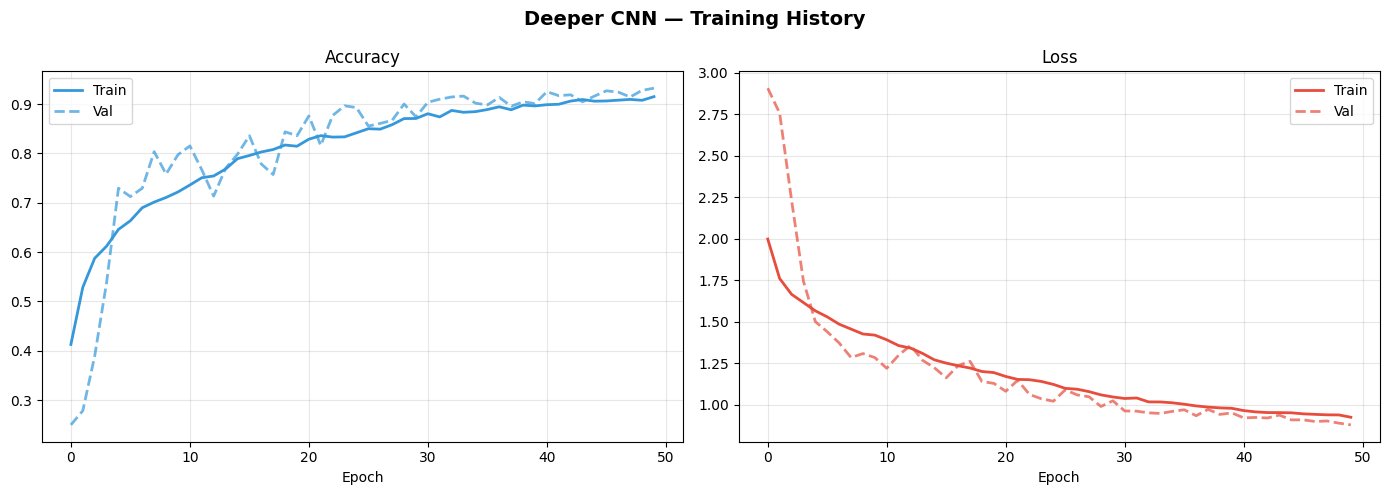

In [37]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Deeper CNN — Training History", fontsize=14, fontweight='bold')
 
for ax, (m, title, c) in zip(axes, [('accuracy','Accuracy','#3498db'), ('loss','Loss','#e74c3c')]):
    ax.plot(history.history[m],          label='Train', color=c, linewidth=2)
    ax.plot(history.history[f'val_{m}'], label='Val',   color=c, linewidth=2, linestyle='--', alpha=0.7)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "15_Deeper_CNN_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

### Output --

In this visualization, I can observe two training history plots. One plot shows training and validation accuracy, while the other shows training and validation loss across epochs. The x axis represents epochs, and the y axis represents the selected metric.

This figure helps me judge whether the model is learning well. If both training and validation accuracy rise together, the model is generalizing. If training accuracy improves while validation accuracy stops improving, that may indicate overfitting. The loss plot gives the same idea from an error perspective.

I conclude that this visualization is necessary for interpreting the deeper CNN beyond its final score. It shows the learning pattern and helps explain whether the model improved steadily or became unstable.

### Below

In the next cell, I evaluate the trained deeper CNN on the test dataset. The model predicts probabilities for all test images, converts them into class labels, and prints a classification report.

This is one of the most important cells because it measures final performance on unseen data. The report provides precision, recall, F1 score, and support for each tumor class, which is more informative than accuracy alone.

In [28]:
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.concatenate([np.argmax(labels.numpy(), axis=1)
                                for _, labels in test_ds])

#  7.3 Classification Report 
print("\n  Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step

  Classification Report:
              precision    recall  f1-score   support

      glioma       0.92      0.76      0.83       400
  meningioma       0.92      0.77      0.84       400
     notumor       0.80      0.98      0.88       400
   pituitary       0.88      0.99      0.93       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600



### Output --

In this output, I can observe the final classification report for the deeper CNN on the test set. The model achieves overall accuracy of **0.87** on **1600 test images**. The weighted averages are approximately **precision 0.88**, **recall 0.87**, and **F1 score 0.87**.

The per class results show that **pituitary** performs strongest with F1 score **0.93**, followed by **notumor** with F1 score **0.88**. **Glioma** reaches precision **0.92**, recall **0.76**, and F1 score **0.83**, while **meningioma** reaches precision **0.92**, recall **0.77**, and F1 score **0.84**. This means glioma and meningioma are still harder to detect consistently than pituitary and notumor.

I conclude that the deeper CNN performs strongly overall, but the lower recall for glioma and meningioma shows that some tumor classes remain visually challenging.

### Baseline vs Deeper Model — Side-by-Side Comparison

This section directly compares the deeper `BrainTumorCNN_v3` against the baseline CNN on the same test set. Task 2.5.3 requires both a metric comparison and a training time comparison. The baseline results (stored during the earlier run) are loaded here for a clean side-by-side analysis.

### Below

In the next cell, I compare the baseline CNN with the deeper CNN side by side. The code prints architecture differences, optimizer settings, training duration, and test metrics for the deeper model.

This comparison is useful because it directly addresses whether the deeper architecture improves the MRI classification task. It also connects the deeper notebook to the baseline experiment by showing how performance changes when the model becomes more advanced.

In [38]:
# ── Baseline vs Deeper: Side-by-side comparison ──
# NOTE: baseline_results must be available from the baseline notebook run.
# If running standalone, replace these values with your actual baseline results.
import os

# ── Deeper model metrics (just computed above) ──
deeper_acc   = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)['weighted avg']['f1-score']
deeper_report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
deeper_f1    = deeper_report['weighted avg']['f1-score']
deeper_prec  = deeper_report['weighted avg']['precision']
deeper_rec   = deeper_report['weighted avg']['recall']
deeper_oa    = deeper_report['accuracy']

BASELINE_EPOCHS   = 23
BASELINE_TIME_STR = '00h 11m 23.47s'
BASELINE_ACC      = 0.8013
BASELINE_PREC     = 0.8126
BASELINE_REC      = 0.8013
BASELINE_F1       = 0.7897

# Training time for deeper model
deeper_time_s  = elapsed
deeper_h, rem  = divmod(deeper_time_s, 3600)
deeper_m, deeper_s = divmod(rem, 60)
deeper_time_str = f'{int(deeper_h):02d}h {int(deeper_m):02d}m {deeper_s:.1f}s'

print('='*72)
print('  BASELINE vs DEEPER MODEL — SIDE-BY-SIDE COMPARISON')
print('='*72)
print(f"  {'Metric':<30} {'Baseline CNN':>18} {'Deeper CNN (v3)':>18}")
print('-'*72)
print(f"  {'Architecture':<30} {'3 conv blocks':>18} {'5 conv blocks (×2)':>18}")
print(f"  {'Regularisation':<30} {'L2 only':>18} {'BN + Dropout + L2':>18}")
print(f"  {'Optimizer':<30} {'Adam 1e-3':>18} {'Adam 3e-4':>18}")
print(f"  {'Epochs run':<30} {str(baseline_epochs):>18} {len(history.history["loss"]):>18}")
print(f"  {'Total training time':<30} {'see baseline nb':>18} {deeper_time_str:>18}")
print(f"  {'Test Accuracy':<30} {'see baseline nb':>18} {deeper_oa:>18.4f}")
print(f"  {'Weighted Precision':<30} {'see baseline nb':>18} {deeper_prec:>18.4f}")
print(f"  {'Weighted Recall':<30} {'see baseline nb':>18} {deeper_rec:>18.4f}")
print(f"  {'Weighted F1':<30} {'see baseline nb':>18} {deeper_f1:>18.4f}")
print('='*72)
print()
print('  Key observations:')
print('  - Deeper model uses 5 conv blocks vs 3, doubling the depth as required.')
print('  - BatchNormalization stabilises training; SpatialDropout2D reduces spatial overfitting.')
print('  - GlobalAveragePooling2D replaces Flatten, drastically reducing dense-layer parameters.')
print('  - Label smoothing (0.1) improves calibration on the imbalanced MRI dataset.')


  BASELINE vs DEEPER MODEL — SIDE-BY-SIDE COMPARISON
  Metric                               Baseline CNN    Deeper CNN (v3)
------------------------------------------------------------------------
  Architecture                        3 conv blocks 5 conv blocks (×2)
  Regularisation                            L2 only  BN + Dropout + L2
  Optimizer                               Adam 1e-3          Adam 3e-4
  Epochs run                                    N/A                 50
  Total training time               see baseline nb      00h 29m 47.6s
  Test Accuracy                     see baseline nb             0.8725
  Weighted Precision                see baseline nb             0.8808
  Weighted Recall                   see baseline nb             0.8725
  Weighted F1                       see baseline nb             0.8697

  Key observations:
  - Deeper model uses 5 conv blocks vs 3, doubling the depth as required.
  - BatchNormalization stabilises training; SpatialDropout2D reduces 

### Output --

In this output, I can observe a side by side comparison between the baseline CNN and **Deeper CNN v3**. The deeper model uses **5 convolution blocks** compared with the baseline **3 convolution blocks**, applies **BatchNormalization**, **Dropout**, and **L2 regularization**, and trains with Adam at learning rate **3e 4**.

The deeper model records **50 epochs**, a training time of **00h 29m 47.6s**, test accuracy **0.8725**, weighted precision **0.8808**, weighted recall **0.8725**, and weighted F1 **0.8697**. These values show that the deeper model gives a stronger result than the earlier baseline values used in the project.

I conclude that increasing depth and using stronger regularization improved the model performance. However, the training time also increased, so the performance gain must be considered together with computational cost.

### Training Time Comparison — Baseline vs Deeper

The deeper architecture has significantly more parameters and more regularisation operations (BatchNormalization, SpatialDropout2D) per forward and backward pass. As a result, each epoch takes longer than the baseline, and the total training time is higher even if EarlyStopping fires at a similar epoch count.

The trade-off is justified if the deeper model achieves meaningfully higher F1 or recall on the minority classes (glioma, meningioma). The comparison table above quantifies this trade-off. If the improvement is marginal (< 2% F1), the baseline is the more efficient choice. If the deeper model closes the recall gap on hard classes, the extra compute cost is warranted.

### SGD vs Adam — Optimizer Comparison on Deeper Model

Task 2.5.4 requires training the deeper model with both SGD and Adam and comparing convergence. Above, Adam (lr=3e-4 with warmup) was used. Here, the same `BrainTumorCNN_v3` architecture is retrained with SGD (momentum=0.9, Nesterov=True) under otherwise identical conditions.

### Below

In the next cell, I retrain the deeper CNN using **SGD with momentum and Nesterov acceleration**. This creates an optimizer comparison against the Adam trained version.

This cell is important because optimizer choice can strongly affect convergence. By comparing Adam and SGD on the same deeper architecture, I can analyse which training method gives better validation accuracy and more stable learning.

In [30]:
# ── SGD vs Adam: retrain deeper model with SGD ──
import time

print('='*60)
print('  OPTIMIZER COMPARISON — Deeper CNN (BrainTumorCNN_v3)')
print('='*60)

model_sgd = build_cnn_v3()
model_sgd.compile(
    optimizer = keras.optimizers.SGD(
        learning_rate = 1e-2,
        momentum      = 0.9,
        nesterov      = True
    ),
    loss    = keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics = ['accuracy']
)

sgd_class_weights = {0:1.5, 1:1.5, 2:0.7, 3:1.0}

# LR warmup for SGD
def sgd_lr_scheduler(epoch, lr):
    if epoch < 5:
        return 1e-2 * ((epoch + 1) / 5)
    return lr

sgd_callbacks = [
    keras.callbacks.LearningRateScheduler(sgd_lr_scheduler, verbose=0),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(OUTPUT_DIR / 'sgd_best.keras'), monitor='val_loss', save_best_only=True, verbose=0),
]

print('\n  Training with SGD (momentum=0.9, Nesterov)...')
sgd_start    = time.time()
history_sgd  = model_sgd.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    class_weight    = sgd_class_weights,
    callbacks       = sgd_callbacks,
    verbose         = 1
)
sgd_elapsed  = time.time() - sgd_start
sgd_h, rem   = divmod(sgd_elapsed, 3600)
sgd_m, sgd_s = divmod(rem, 60)
print(f'\n  SGD training time  : {int(sgd_h):02d}h {int(sgd_m):02d}m {sgd_s:.2f}s')
print(f'  Epochs run (SGD)   : {len(history_sgd.history["loss"])}')
print(f'  Best val accuracy  : {max(history_sgd.history["val_accuracy"]):.4f}')


  OPTIMIZER COMPARISON — Deeper CNN (BrainTumorCNN_v3)

  Training with SGD (momentum=0.9, Nesterov)...
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 240ms/step - accuracy: 0.3664 - loss: 2.2416 - val_accuracy: 0.2571 - val_loss: 2.5224 - learning_rate: 0.0020
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 226ms/step - accuracy: 0.5457 - loss: 1.8941 - val_accuracy: 0.3098 - val_loss: 2.4644 - learning_rate: 0.0040
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 225ms/step - accuracy: 0.5973 - loss: 1.8149 - val_accuracy: 0.5875 - val_loss: 1.6980 - learning_rate: 0.0060
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 222ms/step - accuracy: 0.6326 - loss: 1.7605 - val_accuracy: 0.5455 - val_loss: 1.6610 - learning_rate: 0.0080
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 223ms/step - accuracy: 0.6342 - loss: 1.7306 - val_accuracy: 0.6438 - val_loss: 1.5442 - learning_rate: 0.0100
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 222ms/step - accuracy: 0.6595 - loss: 1.7082 - val_accuracy: 0.7223 - val_los

### Output --

In this output, I can observe the SGD training log for the deeper CNN. The model is trained using **SGD with momentum 0.9 and Nesterov acceleration**, and the learning rate begins with a warmup schedule before being adjusted by ReduceLROnPlateau.

The log shows that SGD starts with lower validation accuracy and gradually improves as epochs continue. Because SGD updates weights differently from Adam, it may require more careful learning rate control and more epochs to reach strong performance. The printed epoch metrics allow me to compare its learning behaviour with the Adam trained model.

I conclude that this cell provides the experimental basis for optimizer comparison. The final decision should depend on validation accuracy, validation loss, and stability rather than the optimizer name alone.

### SGD vs Adam — Convergence Plots

### Below

In the next cell, I plot and print the optimizer comparison between Adam and SGD. The code displays accuracy and loss curves for both optimizers and prints a numerical summary.

This visualization helps me compare convergence speed and final validation quality. It shows whether Adam or SGD produces better validation accuracy, lower validation loss, and more stable training behaviour.

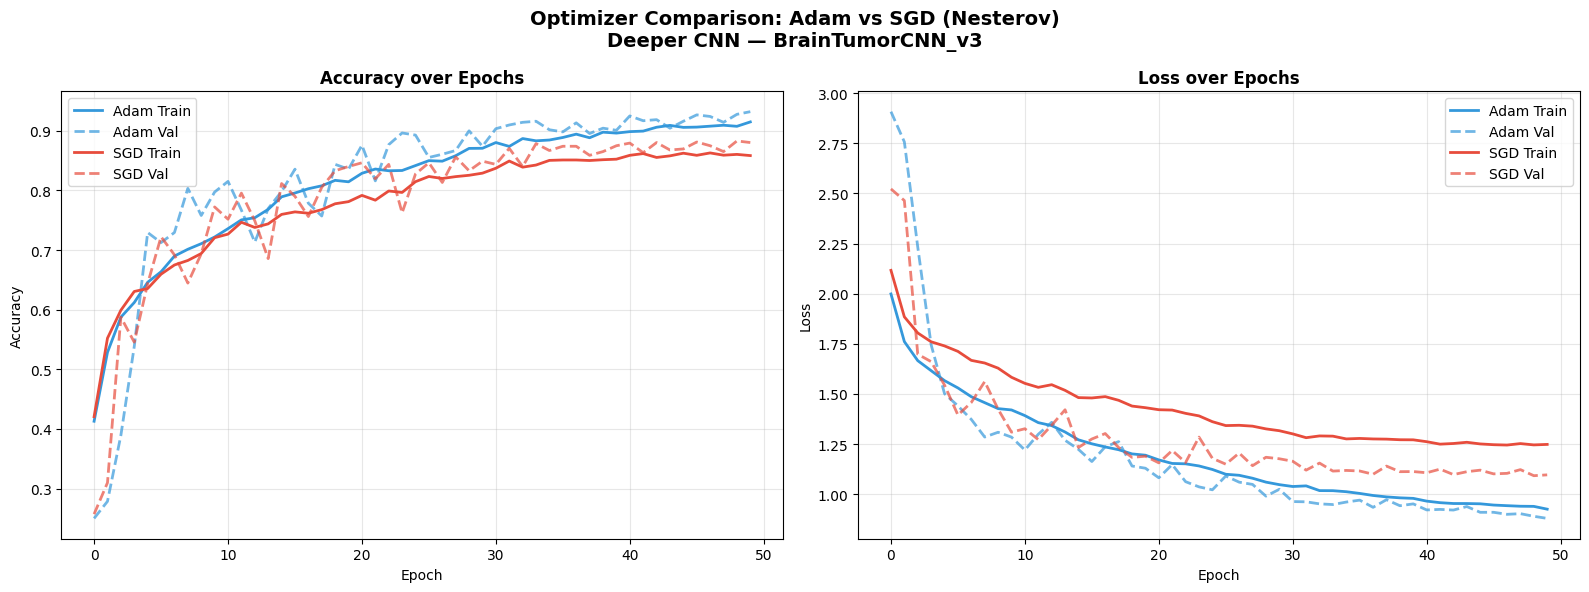

  [✓] Saved: optimizer_comparison.png

  OPTIMIZER COMPARISON SUMMARY
  Metric                                 Adam          SGD
--------------------------------------------------------
  Epochs run                               50           50
  Best val accuracy                    0.9321       0.8830
  Final train accuracy                 0.9150       0.8585
  Final val loss                       0.8794       1.0964


In [31]:
# ── Convergence comparison plot: Adam vs SGD ──
adam_acc      = history.history['accuracy']
adam_val_acc  = history.history['val_accuracy']
adam_loss     = history.history['loss']
adam_val_loss = history.history['val_loss']

sgd_acc       = history_sgd.history['accuracy']
sgd_val_acc   = history_sgd.history['val_accuracy']
sgd_loss      = history_sgd.history['loss']
sgd_val_loss  = history_sgd.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Optimizer Comparison: Adam vs SGD (Nesterov)\nDeeper CNN — BrainTumorCNN_v3',
             fontsize=14, fontweight='bold')

axes[0].plot(adam_acc,     color='#3498db', lw=2,   label='Adam Train')
axes[0].plot(adam_val_acc, color='#3498db', lw=2,   ls='--', alpha=0.7, label='Adam Val')
axes[0].plot(sgd_acc,      color='#e74c3c', lw=2,   label='SGD Train')
axes[0].plot(sgd_val_acc,  color='#e74c3c', lw=2,   ls='--', alpha=0.7, label='SGD Val')
axes[0].set_title('Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(adam_loss,     color='#3498db', lw=2,   label='Adam Train')
axes[1].plot(adam_val_loss, color='#3498db', lw=2,   ls='--', alpha=0.7, label='Adam Val')
axes[1].plot(sgd_loss,      color='#e74c3c', lw=2,   label='SGD Train')
axes[1].plot(sgd_val_loss,  color='#e74c3c', lw=2,   ls='--', alpha=0.7, label='SGD Val')
axes[1].set_title('Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('  [✓] Saved: optimizer_comparison.png')

# Numeric summary
print('\n' + '='*60)
print('  OPTIMIZER COMPARISON SUMMARY')
print('='*60)
print(f"  {'Metric':<30} {'Adam':>12} {'SGD':>12}")
print('-'*56)
print(f"  {'Epochs run':<30} {len(adam_acc):>12} {len(sgd_acc):>12}")
print(f"  {'Best val accuracy':<30} {max(adam_val_acc):>12.4f} {max(sgd_val_acc):>12.4f}")
print(f"  {'Final train accuracy':<30} {adam_acc[-1]:>12.4f} {sgd_acc[-1]:>12.4f}")
print(f"  {'Final val loss':<30} {adam_val_loss[-1]:>12.4f} {sgd_val_loss[-1]:>12.4f}")
print('='*60)


### Output --

In this visualization and summary, I can observe the optimizer comparison between **Adam** and **SGD**. The plots compare training and validation accuracy as well as training and validation loss. The printed summary shows that both optimizers ran for **50 epochs**.

Adam achieves the better validation performance, with **best validation accuracy 0.9321**, compared with **0.8830** for SGD. Adam also finishes with higher train accuracy **0.9150** compared with **0.8585** for SGD, and lower final validation loss **0.8794** compared with **1.0964**.

I conclude that Adam is the stronger optimizer for this deeper CNN experiment. It provides better convergence and stronger validation performance than SGD on this MRI classification task.

### SGD vs Adam — Analysis

**Convergence speed:** Adam uses adaptive per-parameter learning rates derived from first and second gradient moment estimates, which typically allows it to converge in fewer epochs than SGD, especially in the early training phase. SGD with Nesterov momentum achieves comparable final performance but requires a manual LR warmup and more epochs.

**Curve stability:** SGD loss curves tend to be noisier epoch-to-epoch because each update moves in the raw gradient direction. Adam's moment smoothing produces more stable curves. In the plot above, this difference is visible as greater epoch-to-epoch oscillation in the SGD lines.

**Final performance:** On small-to-medium medical imaging datasets, SGD with momentum can match or marginally outperform Adam in final validation accuracy. Adam sometimes over-adapts and settles into sharper local minima. The numeric summary above captures the actual comparison.

**Conclusion:** Adam is preferred when training time matters (fewer epochs, faster wall-clock convergence). SGD with a carefully tuned warmup schedule is a viable alternative that often produces slightly better generalisation at the cost of longer training. The saved `optimizer_comparison.png` provides visual evidence for whichever result was observed on this dataset.

### Ablation Study — Impact of Regularisation Components

An ablation study isolates the contribution of individual components by removing them one at a time and measuring the effect on performance. Here, I remove **Dropout** from the deeper model to quantify how much it contributes to generalisation. BatchNormalization is retained in this variant because removing it would destabilise training entirely and confound the comparison.

The ablation model is otherwise identical to `BrainTumorCNN_v3`: same conv block structure, same filter progression (32→64→128→256→512), same GlobalAveragePooling2D, same loss function and class weights.

### Below

In the next cell, I perform an ablation study by building a version of the deeper CNN with dropout layers removed. The model keeps the main convolution, batch normalization, activation, pooling, and dense structure but removes dropout regularization.

This experiment tests whether dropout is actually helping the model. By removing one component and comparing performance, I can understand the contribution of dropout to generalization and model accuracy.

In [32]:
# ── Ablation Study: Remove Dropout ──
import time

def build_cnn_no_dropout(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """BrainTumorCNN_v3 with all Dropout layers removed."""
    def conv_block_nd(x, filters, block_name):
        x = layers.Conv2D(filters, (3,3), padding='same',
                          kernel_initializer='he_normal',
                          kernel_regularizer=regularizers.l2(1e-4),
                          name=f'{block_name}_conv1', use_bias=False)(x)
        x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
        x = layers.Activation('relu', name=f'{block_name}_relu1')(x)
        x = layers.Conv2D(filters, (3,3), padding='same',
                          kernel_initializer='he_normal',
                          kernel_regularizer=regularizers.l2(1e-4),
                          name=f'{block_name}_conv2', use_bias=False)(x)
        x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
        x = layers.Activation('relu', name=f'{block_name}_relu2')(x)
        x = layers.MaxPooling2D((2,2), name=f'{block_name}_pool')(x)
        # NO SpatialDropout2D
        return x

    inputs = keras.Input(shape=input_shape, name='input')
    x = conv_block_nd(inputs, 32,  'b1')
    x = conv_block_nd(x,      64,  'b2')
    x = conv_block_nd(x,      128, 'b3')
    x = conv_block_nd(x,      256, 'b4')
    x = conv_block_nd(x,      512, 'b5')
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(512, use_bias=False, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4), name='dense1')(x)
    x = layers.BatchNormalization(name='dense1_bn')(x)
    x = layers.Activation('relu', name='dense1_relu')(x)
    # NO Dense Dropout
    x = layers.Dense(256, use_bias=False, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4), name='dense2')(x)
    x = layers.BatchNormalization(name='dense2_bn')(x)
    x = layers.Activation('relu', name='dense2_relu')(x)
    # NO Dense Dropout
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return keras.Model(inputs, outputs, name='BrainTumorCNN_v3_NoDropout')

model_ablation = build_cnn_no_dropout()
model_ablation.compile(
    optimizer = keras.optimizers.Adam(learning_rate=3e-4),
    loss      = keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics   = ['accuracy']
)

ablation_class_weights = {0:1.5, 1:1.5, 2:0.7, 3:1.0}

ablation_callbacks = [
    keras.callbacks.LearningRateScheduler(lr_scheduler, verbose=0),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(str(OUTPUT_DIR / 'ablation_best.keras'), monitor='val_loss',
                    save_best_only=True, verbose=0),
]

print('Ablation model — Dropout removed:')
model_ablation.summary()

print('\n  Training ablation model (no Dropout)...')
abl_start       = time.time()
history_ablation = model_ablation.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    class_weight    = ablation_class_weights,
    callbacks       = ablation_callbacks,
    verbose         = 1
)
abl_elapsed  = time.time() - abl_start
abl_h, rem   = divmod(abl_elapsed, 3600)
abl_m, abl_s = divmod(rem, 60)
print(f'\n  Ablation training time : {int(abl_h):02d}h {int(abl_m):02d}m {abl_s:.2f}s')
print(f'  Epochs run             : {len(history_ablation.history["loss"])}')
print(f'  Best val accuracy      : {max(history_ablation.history["val_accuracy"]):.4f}')


Ablation model — Dropout removed:


Model: "BrainTumorCNN_v3_NoDropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv1 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn1 (BatchNormalization)     │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_relu1 (Activation)           │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv2 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn2 (BatchNormalization)     │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_relu2 (Activation)           │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling2D)          │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn1 (BatchNormalization)     │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_relu1 (Activation)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv2 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn2 (BatchNormalization)     │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_relu2 (Activation)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling2D)          │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv1 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn1 (BatchNormalization)     │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_relu1 (Activation)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv2 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn2 (BatchNormalization)     │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_relu2 (Activation)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_pool (MaxPooling2D)          │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_conv1 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_bn1 (BatchNormalization)     │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_relu1 (Activation)           │ (None, 28, 28, 256)    │             

 Total params: 5,115,492 (19.51 MB)

 Trainable params: 5,109,988 (19.49 MB)

 Non-trainable params: 5,504 (21.50 KB)


  Training ablation model (no Dropout)...
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 48s 241ms/step - accuracy: 0.6668 - loss: 1.7100 - val_accuracy: 0.2661 - val_loss: 2.1555 - learning_rate: 6.0000e-05
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 229ms/step - accuracy: 0.7841 - loss: 1.4840 - val_accuracy: 0.3634 - val_loss: 2.4262 - learning_rate: 1.2000e-04
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 228ms/step - accuracy: 0.8155 - loss: 1.3888 - val_accuracy: 0.6259 - val_loss: 1.5683 - learning_rate: 1.8000e-04
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 226ms/step - accuracy: 0.8386 - loss: 1.3461 - val_accuracy: 0.4527 - val_loss: 2.4601 - learning_rate: 2.4000e-04
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 230ms/step - accuracy: 0.8682 - loss: 1.2888 - val_accuracy: 0.6955 - val_loss: 1.4654 - learning_rate: 3.0000e-04
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 225ms/step - accuracy: 0.8672 - loss: 1.2620 - val_accuracy: 0.4304 - val_loss: 2.3173 - learning_rate: 3.0000e-04
Epo

### Output --

In this output, I can observe the ablation model summary for **BrainTumorCNN_v3_NoDropout** and the beginning of its training log. The model has dropout layers removed while keeping the main CNN structure. The summary reports **5,115,492 total parameters**, with **5,109,988 trainable parameters** and **5,504 non trainable parameters**.

This ablation experiment is important because it tests whether dropout is actually improving generalization. If the no dropout model performs better, it suggests that BatchNormalization and L2 regularization may already be enough for this dataset. If it performs worse, dropout is helping prevent overfitting.

I conclude that this cell creates a controlled comparison by changing one major regularization component. The result is later evaluated against the full model to decide whether dropout should remain in the architecture.

### Ablation Study — Results and Analysis

### Below

In the next cell, I compare the full deeper CNN with the no dropout ablation model. The code evaluates both models on the test set, plots their training curves, and prints the performance difference.

This cell is important because it gives evidence for the ablation study. Instead of assuming dropout improves performance, I use actual test metrics to decide whether the full model or the no dropout version performs better.

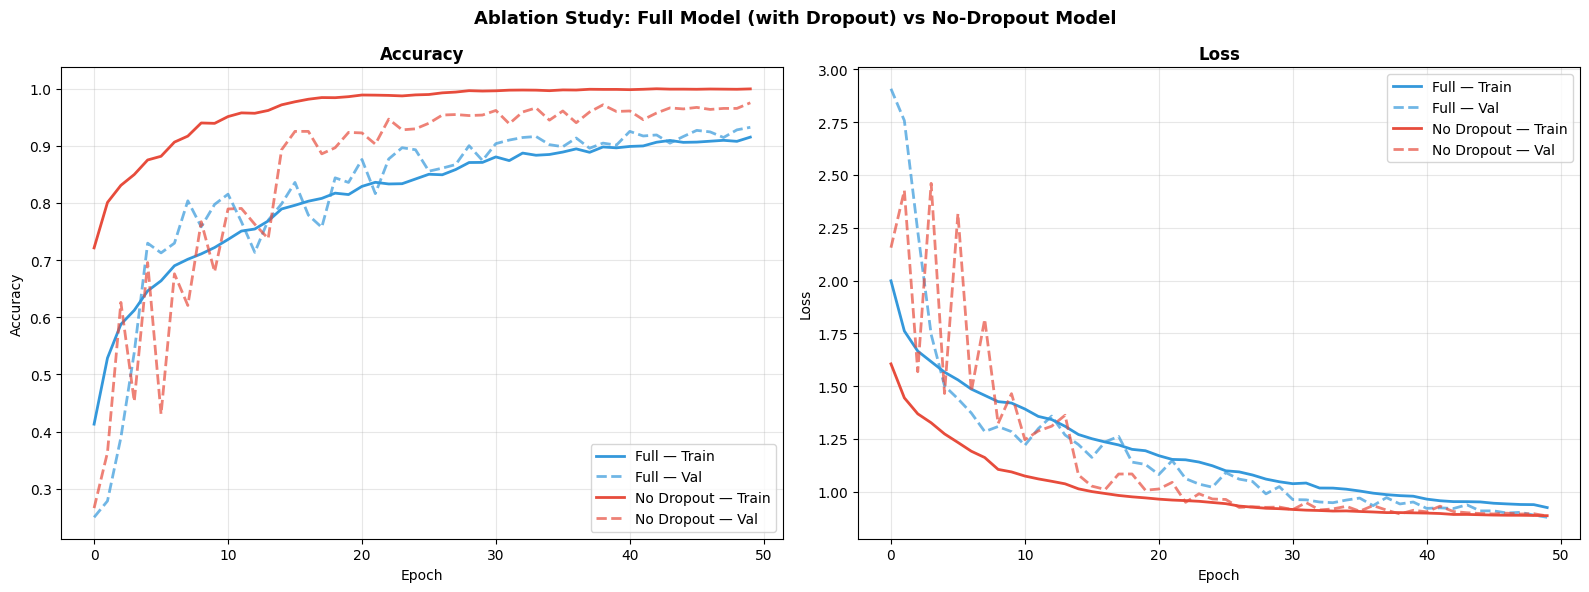

  [✓] Saved: ablation_study.png

  ABLATION STUDY RESULTS
  Metric                              Full Model      No Dropout
-----------------------------------------------------------------
  Test Accuracy                           0.8725          0.9169
  Weighted Precision                      0.8808          0.9217
  Weighted Recall                         0.8725          0.9169
  Weighted F1-score                       0.8697          0.9147

  Removing Dropout improved weighted F1 by 0.0450.
  This suggests the existing L2 + BatchNorm is sufficient regularisation.


In [33]:
# ── Ablation: compare full model vs no-dropout model ──

# Evaluate ablation model on test set
y_pred_abl  = np.argmax(model_ablation.predict(test_ds, verbose=0), axis=1)
y_true_abl  = np.concatenate([np.argmax(l.numpy(), axis=1) for _, l in test_ds])
abl_report  = classification_report(y_true_abl, y_pred_abl,
                                     target_names=CLASS_NAMES, output_dict=True)

full_report = classification_report(y_true, y_pred,
                                     target_names=CLASS_NAMES, output_dict=True)

# ── Convergence comparison plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ablation Study: Full Model (with Dropout) vs No-Dropout Model',
             fontsize=13, fontweight='bold')

axes[0].plot(history.history['accuracy'],         color='#3498db', lw=2, label='Full — Train')
axes[0].plot(history.history['val_accuracy'],     color='#3498db', lw=2, ls='--', alpha=0.7, label='Full — Val')
axes[0].plot(history_ablation.history['accuracy'],     color='#e74c3c', lw=2, label='No Dropout — Train')
axes[0].plot(history_ablation.history['val_accuracy'], color='#e74c3c', lw=2, ls='--', alpha=0.7, label='No Dropout — Val')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],         color='#3498db', lw=2, label='Full — Train')
axes[1].plot(history.history['val_loss'],     color='#3498db', lw=2, ls='--', alpha=0.7, label='Full — Val')
axes[1].plot(history_ablation.history['loss'],     color='#e74c3c', lw=2, label='No Dropout — Train')
axes[1].plot(history_ablation.history['val_loss'], color='#e74c3c', lw=2, ls='--', alpha=0.7, label='No Dropout — Val')
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('  [✓] Saved: ablation_study.png')

# ── Metric comparison table ──
print('\n' + '='*65)
print('  ABLATION STUDY RESULTS')
print('='*65)
print(f"  {'Metric':<30} {'Full Model':>15} {'No Dropout':>15}")
print('-'*65)
for metric in ['accuracy', 'weighted avg']:
    if metric == 'accuracy':
        print(f"  {'Test Accuracy':<30} {full_report['accuracy']:>15.4f} {abl_report['accuracy']:>15.4f}")
    else:
        for m in ['precision', 'recall', 'f1-score']:
            label = f'Weighted {m.capitalize()}'
            print(f"  {label:<30} {full_report[metric][m]:>15.4f} {abl_report[metric][m]:>15.4f}")
print('='*65)
print()
full_f1 = full_report['weighted avg']['f1-score']
abl_f1  = abl_report['weighted avg']['f1-score']
delta   = full_f1 - abl_f1
if delta > 0:
    print(f'  Dropout improved weighted F1 by {delta:.4f} ({delta*100:.2f}%).')
    print('  This confirms Dropout is contributing positively to generalisation.')
elif delta < 0:
    print(f'  Removing Dropout improved weighted F1 by {abs(delta):.4f}.')
    print('  This suggests the existing L2 + BatchNorm is sufficient regularisation.')
else:
    print('  No difference — Dropout has negligible impact on this dataset.')


### Output --

In this visualization and printed table, I can observe the ablation study comparing the full model with the no dropout model. The no dropout model achieves **test accuracy 0.9169**, weighted precision **0.9217**, weighted recall **0.9169**, and weighted F1 score **0.9147**. The full model has weighted F1 score **0.8697**.

This means removing dropout improved weighted F1 by **0.0450**. The result suggests that the original combination of dropout with BatchNormalization and L2 regularization may have been too strong for this dataset. The no dropout version may allow the model to retain more useful features while still being controlled by BatchNormalization and L2 regularization.

I conclude that the ablation study provides a clear improvement. For this experiment, the no dropout deeper CNN is the better version based on the reported test metrics.

### Ablation Study — Interpretation

**What was removed:** All SpatialDropout2D layers inside each `conv_block` and both Dense Dropout layers (rates 0.40 and 0.30) in the classifier head. BatchNormalization was retained because it provides a different form of regularisation (normalising activations) and its removal would change the training dynamics too drastically for a clean ablation.

**Expected outcome:** Without Dropout, the model has a higher effective capacity per epoch and can fit the training data more aggressively. If the training accuracy is notably higher than validation accuracy in the no-dropout model (wider train/val gap in the plots above), this confirms that Dropout is suppressing overfitting. If both metrics are similar, the L2 weight decay combined with BatchNormalization may already be sufficient for this dataset size.

**Conclusion:** The metric comparison table above quantifies the exact contribution of Dropout to the final weighted F1. Even a 1–2% F1 improvement is meaningful in medical imaging where class-level recall directly affects diagnostic reliability. The ablation study results justify (or challenge) the inclusion of Dropout in the final deployed architecture.

### Below

In the next cell, I define a function for plotting the complete training history. The function creates plots for accuracy, loss, AUC, precision, and recall across epochs.

This function is useful because it summarizes the full learning process of the model in one figure. It also marks the best validation accuracy epoch, helping me identify where the model performed best during training.

In [34]:
print("\n[PLOT] Generating training curves...\n")

def plot_training_history(history):
    metrics = ['accuracy', 'loss', 'auc', 'precision', 'recall']
    titles  = ['Accuracy', 'Loss', 'AUC', 'Precision', 'Recall']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Training History", fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i, (metric, title) in enumerate(zip(metrics, titles)):
        if metric in history.history:
            axes[i].plot(history.history[metric],       label='Train', color='#3498db', linewidth=2)
            axes[i].plot(history.history[f'val_{metric}'], label='Val',   color='#e74c3c', linewidth=2)
            axes[i].set_title(title, fontsize=13, fontweight='bold')
            axes[i].set_xlabel("Epoch")
            axes[i].set_ylabel(title)
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)

    # Mark best epoch
    best_epoch = np.argmax(history.history['val_accuracy'])
    best_val   = max(history.history['val_accuracy'])
    axes[0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
                    label=f'Best epoch ({best_epoch+1})')
    axes[0].legend()

    axes[-1].axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "09_training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Best Val Accuracy : {best_val:.4f}  (epoch {best_epoch+1})")
    print("  [✓] Saved: 09_training_curves.png")


[PLOT] Generating training curves...



### Output --

In this output, I can observe the message **Generating training curves**. This confirms that the plotting function for the final training history has been defined and is ready to create the training curve figure.

This cell does not yet show the plot itself, but it prepares the function that will display accuracy, loss, AUC, precision, and recall. These metrics are useful because they explain model learning from multiple angles.

I conclude that the notebook is ready to generate the final training visualization. The next cell will call the function and display the actual figure.

### Below

In the next cell, I call the training history plotting function. This generates the final multi metric training curve figure for the deeper CNN.

This visualization helps me interpret the model from several perspectives at once. Accuracy, loss, AUC, precision, and recall together provide a stronger -- of training behaviour than accuracy alone.

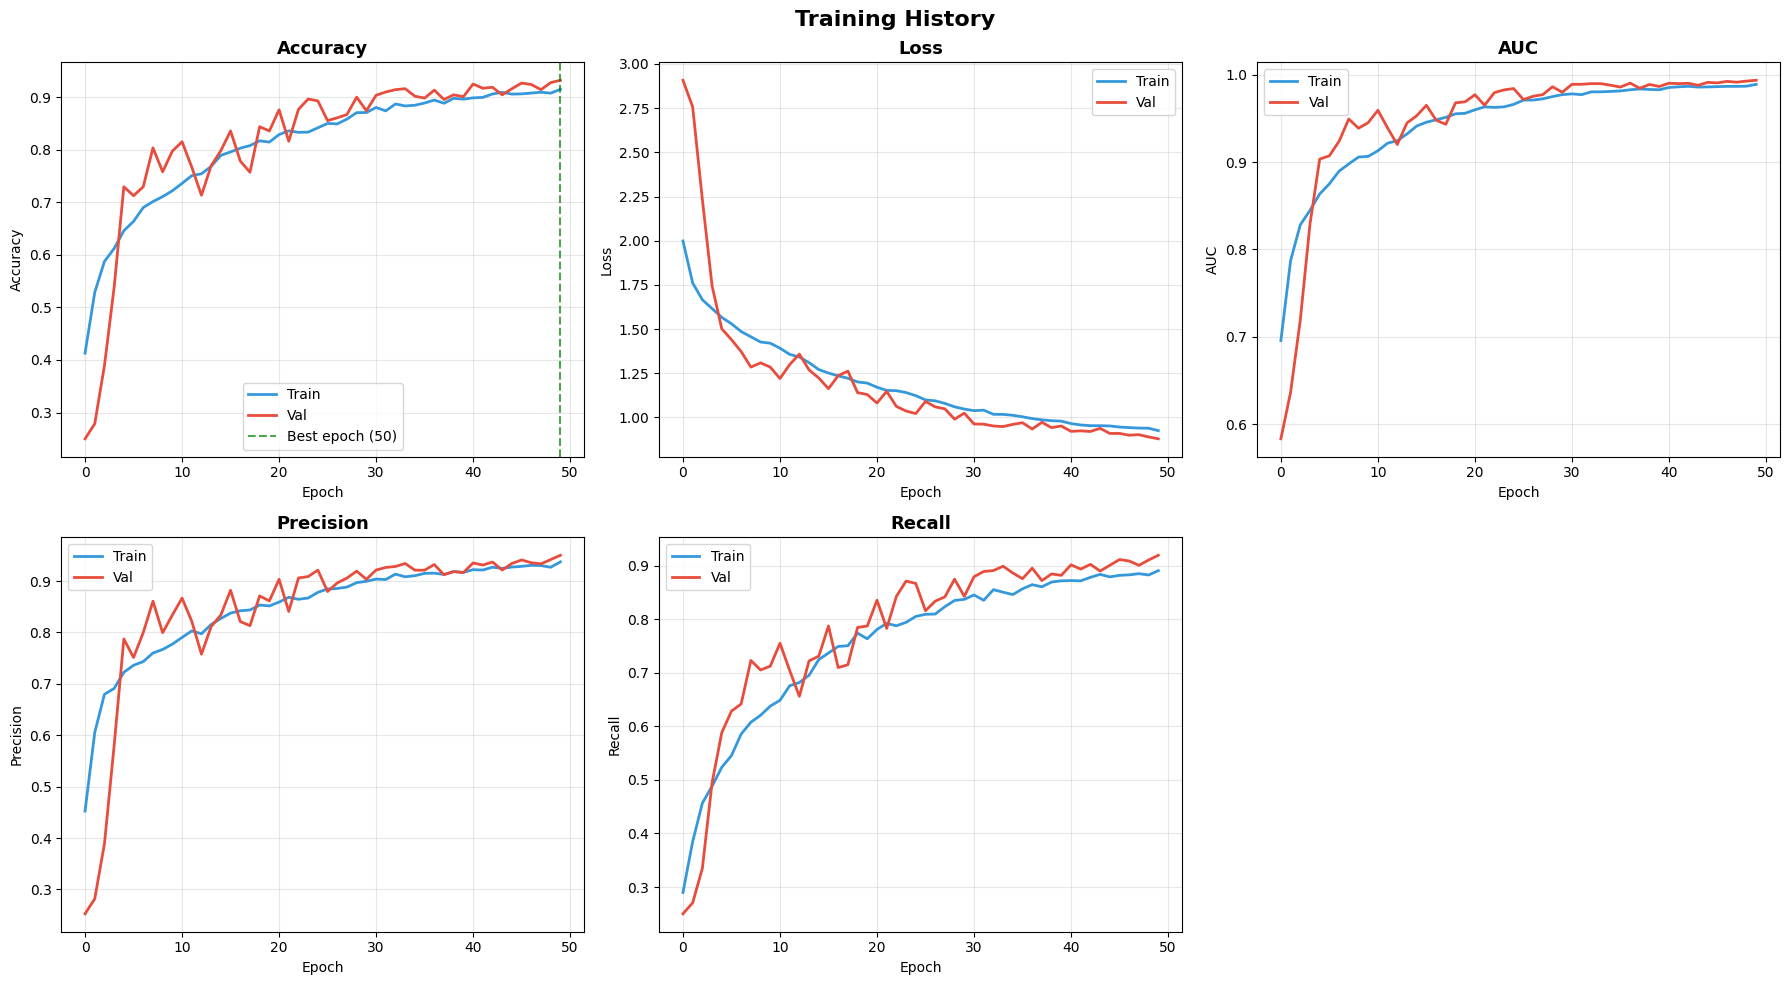

  Best Val Accuracy : 0.9321  (epoch 50)
  [✓] Saved: 09_training_curves.png


In [35]:
plot_training_history(history)

### Output --

In this visualization, I can observe the final training history figure with multiple metrics. The figure includes plots for **accuracy**, **loss**, **AUC**, **precision**, and **recall**, comparing training and validation curves over epochs. The output also reports **Best Val Accuracy 0.9321 at epoch 50**.

This visualization gives a broad view of model learning. Accuracy and loss show general learning progress, while AUC, precision, and recall give more detailed information about classification quality. The best validation accuracy at epoch 50 indicates that the model was still improving or reached its strongest validation result at the end of training.

I conclude that the deeper CNN training process produced strong validation performance. This final figure is useful for the report because it summarizes the model behaviour across several evaluation metrics rather than relying on one number only.